In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, cv2, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from torchvision import transforms, models
from transformers import BertTokenizer, BertForSequenceClassification
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All imports done!")
print(f"🖥️  Device : {device}")
print(f"🔥 GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU!'}")

Mounted at /content/drive
✅ All imports done!
🖥️  Device : cuda
🔥 GPU    : Tesla T4


In [ ]:
BASE_PATH         = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
BERT_MODEL_PATH   = os.path.join(BASE_PATH, "models/bert_model")
CNN_IMAGE_PATH    = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_best.pth")
CNN_VIDEO_PATH    = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_video_finetuned.pth")
GRAPHS_SAVE_PATH  = os.path.join(BASE_PATH, "outputs/graphs")
FUSION_SAVE_PATH  = os.path.join(BASE_PATH, "outputs/predictions")

os.makedirs(GRAPHS_SAVE_PATH, exist_ok=True)
os.makedirs(FUSION_SAVE_PATH, exist_ok=True)

print("✅ Paths configured!")
print(f"   BERT model  : {BERT_MODEL_PATH}")
print(f"   CNN image   : {CNN_IMAGE_PATH}")
print(f"   CNN video   : {CNN_VIDEO_PATH}")

# Verify all model files exist
print("\n🔍 Checking model files...")
for name, path in [
    ("BERT",      BERT_MODEL_PATH),
    ("CNN Image", CNN_IMAGE_PATH),
    ("CNN Video", CNN_VIDEO_PATH)]:
    exists = os.path.exists(path)
    size   = (os.path.getsize(path)/1024**2
              if os.path.isfile(path) else
              sum(os.path.getsize(os.path.join(path,f))
                  for f in os.listdir(path))/1024**2
              if os.path.isdir(path) else 0)
    print(f"   {'✅' if exists else '❌'} {name:<12}: {size:.1f} MB")

✅ Paths configured!
   BERT model  : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/bert_model
   CNN image   : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_best.pth
   CNN video   : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_video_finetuned.pth

🔍 Checking model files...
   ✅ BERT        : 417.9 MB
   ✅ CNN Image   : 18.1 MB
   ✅ CNN Video   : 18.1 MB


In [ ]:
!pip install -q transformers==4.35.0

print("⏳ Loading BERT model...")
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_PATH)
bert_model     = BertForSequenceClassification.from_pretrained(BERT_MODEL_PATH)
bert_model     = bert_model.to(device)
bert_model.eval()
print("✅ BERT model loaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.6.0 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.35.0 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.17.3 which is incompatible.
accelerate 1.14.0 requires huggingface_hub>=0.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BERT model loaded!


In [ ]:
def build_efficientnet(num_classes=2, dropout=0.3):
    """Rebuild exact EfficientNetB0 architecture used in training."""
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters():
        param.requires_grad = False
    for param in m.features[6:].parameters():
        param.requires_grad = True
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout/2),
        nn.Linear(512, num_classes)
    )
    return m

# ── Load image model ─────────────────────────────────────────
print("⏳ Loading CNN image model...")
cnn_image_model = build_efficientnet()
weights = torch.load(CNN_IMAGE_PATH, map_location=device)
cnn_image_model.load_state_dict(
    weights['model_state'] if 'model_state' in weights else weights)
cnn_image_model = cnn_image_model.to(device)
cnn_image_model.eval()
print("✅ CNN image model loaded!")

# ── Load video model ─────────────────────────────────────────
print("⏳ Loading CNN video model...")
cnn_video_model = build_efficientnet()
weights = torch.load(CNN_VIDEO_PATH, map_location=device)
cnn_video_model.load_state_dict(
    weights['model_state'] if 'model_state' in weights else weights)
cnn_video_model = cnn_video_model.to(device)
cnn_video_model.eval()
print("✅ CNN video model loaded!")

print(f"\n✅ All 3 models loaded and ready!")
print(f"   Device: {next(bert_model.parameters()).device}")

⏳ Loading CNN image model...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 102MB/s]


✅ CNN image model loaded!
⏳ Loading CNN video model...
✅ CNN video model loaded!

✅ All 3 models loaded and ready!
   Device: cuda:0


In [ ]:
# ── Reload correct models ────────────────────────────────────
print("🔄 Reloading correct model for video...")

VIDEO_CORRECT_PATH = os.path.join(
    BASE_PATH,
    "models/cnn_model/efficientnet_video_finetuned.pth")

# Reload video model with ORIGINAL fine-tuned weights
cnn_video_model = build_efficientnet()
w = torch.load(VIDEO_CORRECT_PATH, map_location=device)
cnn_video_model.load_state_dict(
    w['model_state'] if 'model_state' in w else w)
cnn_video_model = cnn_video_model.to(device)
cnn_video_model.eval()
print("✅ Original video model restored!")

# Image model stays as combined (97.72%) ✅
print("✅ Image model stays as combined CNN (face + AI generated)")

# Quick sanity check
print("\n🔍 Sanity check — testing your own face video...")
print("   Upload your face video to verify:")

🔄 Reloading correct model for video...
✅ Original video model restored!
✅ Image model stays as combined CNN (face + AI generated)

🔍 Sanity check — testing your own face video...
   Upload your face video to verify:


In [ ]:
# ── Image transform (same as training) ──────────────────────
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── 1. BERT — Text Prediction ────────────────────────────────
def predict_text(text, model, tokenizer, device, max_len=128):
    """
    Predict whether text is Fake or Real news.
    Returns fake_probability (0-1).
    """
    model.eval()
    enc = tokenizer(
        text.lower().strip(),
        max_length=max_len, truncation=True,
        padding='max_length', return_tensors='pt'
    )
    with torch.no_grad():
        probs = torch.softmax(
            model(input_ids=enc['input_ids'].to(device),
                  attention_mask=enc['attention_mask'].to(device)
                  ).logits, dim=1)
    # BERT: index 1 = Fake
    return probs[0][1].item()


# ── 2. CNN — Image Prediction ────────────────────────────────
def predict_image(image_path, model, device):
    """
    Predict whether an image is Deepfake or Real.
    Returns fake_probability (0-1).
    """
    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = image_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)
    # CNN: index 0 = Fake
    return probs[0][0].item()


# ── 3. CNN — Video Prediction ────────────────────────────────
def predict_video(video_path, model, device, num_frames=20):
    """
    Predict whether a video is Deepfake or Real using OpenCV.
    Extracts frames → runs CNN → averages probabilities.
    Returns fake_probability (0-1).
    """
    cap      = cv2.VideoCapture(video_path)
    total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    duration = total / fps if fps > 0 else 0

    if total == 0:
        cap.release()
        return None

    indices    = np.linspace(0, total-1,
                             min(num_frames, total), dtype=int)
    fake_probs = []
    model.eval()

    with torch.no_grad():
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img       = Image.fromarray(frame_rgb)
                tensor    = image_transform(img).unsqueeze(0).to(device)
                probs     = torch.softmax(model(tensor), dim=1)
                fake_probs.append(probs[0][0].item())
    cap.release()

    return np.mean(fake_probs) if fake_probs else None


print("✅ All prediction functions ready!")
print("   predict_text()  → BERT fake news detection")
print("   predict_image() → CNN image deepfake detection")
print("   predict_video() → CNN video deepfake detection")

✅ All prediction functions ready!
   predict_text()  → BERT fake news detection
   predict_image() → CNN image deepfake detection
   predict_video() → CNN video deepfake detection


In [ ]:
def multimodal_fusion(
    text=None,
    image_path=None,
    video_path=None,
    text_weight=0.4,
    image_weight=0.3,
    video_weight=0.3,
    threshold=0.5
):
    """
    Multimodal Fusion — combines BERT + CNN Image + CNN Video.

    Strategy: Weighted average of available modality scores.
    Weights automatically renormalised if not all modalities provided.

    Args:
        text        : news article string (optional)
        image_path  : path to image file  (optional)
        video_path  : path to video file  (optional)
        text_weight : weight for BERT score  (default 0.4)
        image_weight: weight for image score (default 0.3)
        video_weight: weight for video score (default 0.3)
        threshold   : fake decision boundary (default 0.5)

    Returns:
        dict with verdict, confidence, per-modality scores
    """
    scores  = {}
    weights = {}

    # ── Run each available modality ──────────────────────────
    if text is not None and text.strip():
        score = predict_text(
            text, bert_model, bert_tokenizer, device)
        scores['text']   = score
        weights['text']  = text_weight
        print(f"   📝 Text  score : {score*100:.1f}% fake")

    if image_path is not None and os.path.exists(image_path):
        score = predict_image(image_path, cnn_image_model, device)
        scores['image']  = score
        weights['image'] = image_weight
        print(f"   🖼️  Image score : {score*100:.1f}% fake")

    if video_path is not None and os.path.exists(video_path):
        score = predict_video(video_path, cnn_video_model, device)
        if score is not None:
            scores['video']  = score
            weights['video'] = video_weight
            print(f"   🎬 Video score : {score*100:.1f}% fake")

    if not scores:
        return {"error": "No valid input provided!"}

    # ── Normalise weights to sum to 1.0 ─────────────────────
    total_weight = sum(weights[k] for k in scores)
    norm_weights = {k: weights[k]/total_weight for k in scores}

    # ── Compute weighted fusion score ────────────────────────
    fusion_score = sum(
        scores[k] * norm_weights[k] for k in scores)

    # ── Final verdict ────────────────────────────────────────
    verdict    = "🔴 FAKE" if fusion_score >= threshold else "🟢 REAL"
    conf_fake  = fusion_score * 100
    conf_real  = (1 - fusion_score) * 100

    return {
        "verdict"       : verdict,
        "fusion_score"  : round(fusion_score, 4),
        "confidence_fake": round(conf_fake, 2),
        "confidence_real": round(conf_real, 2),
        "modalities_used": list(scores.keys()),
        "individual_scores": {
            k: round(v*100, 2) for k, v in scores.items()},
        "weights_used": {
            k: round(norm_weights[k], 3) for k in scores}
    }


print("✅ Multimodal fusion function ready!")
print("\n💡 Fusion weights:")
print("   Text  : 40%  (BERT fake news)")
print("   Image : 30%  (CNN deepfake image)")
print("   Video : 30%  (CNN deepfake video)")
print("\n💡 Auto weight normalisation:")
print("   Text only  → Text 100%")
print("   Text+Image → Text 57%, Image 43%")
print("   All three  → Text 40%, Image 30%, Video 30%")

✅ Multimodal fusion function ready!

💡 Fusion weights:
   Text  : 40%  (BERT fake news)
   Image : 30%  (CNN deepfake image)
   Video : 30%  (CNN deepfake video)

💡 Auto weight normalisation:
   Text only  → Text 100%
   Text+Image → Text 57%, Image 43%
   All three  → Text 40%, Image 30%, Video 30%


In [ ]:
def display_fusion_result(result, text=None,
                          image_path=None, video_path=None):
    """Display fusion results in a clean visual format."""

    if "error" in result:
        print(f"❌ Error: {result['error']}")
        return

    verdict     = result['verdict']
    conf_fake   = result['confidence_fake']
    conf_real   = result['confidence_real']
    modalities  = result['modalities_used']
    ind_scores  = result['individual_scores']
    color       = 'red' if 'FAKE' in verdict else 'green'

    print("\n" + "="*60)
    print(f"  🔍 MULTIMODAL FUSION RESULT")
    print("="*60)
    print(f"  Verdict     : {verdict}")
    print(f"  Fake conf   : {conf_fake:.1f}%")
    print(f"  Real conf   : {conf_real:.1f}%")
    print(f"  Modalities  : {', '.join(modalities)}")
    print("-"*60)
    print("  Individual scores:")
    for mod, score in ind_scores.items():
        bar   = "█" * int(score/5) + "░" * (20 - int(score/5))
        emoji = "📝" if mod=="text" else "🖼️" if mod=="image" else "🎬"
        print(f"  {emoji} {mod:<6}: {bar} {score:.1f}%")
    print("="*60)

    # ── Visualisation ────────────────────────────────────────
    n_mods = len(modalities)
    fig    = plt.figure(figsize=(14, 5))

    # Bar chart of scores
    ax1 = fig.add_subplot(1, 3, 1)
    mod_names  = list(ind_scores.keys())
    mod_scores = list(ind_scores.values())
    bar_colors = ['#e74c3c' if s >= 50 else '#2ecc71'
                  for s in mod_scores]
    bars = ax1.bar(mod_names, mod_scores,
                   color=bar_colors, edgecolor='black',
                   width=0.5)
    ax1.axhline(y=50, color='gray', linestyle='--',
                linewidth=1.5, label='Threshold (50%)')
    ax1.set_ylim([0, 100])
    ax1.set_title('Per-Modality Fake Score',
                  fontweight='bold')
    ax1.set_ylabel('Fake Probability (%)')
    ax1.legend(fontsize=9)
    for bar, score in zip(bars, mod_scores):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{score:.1f}%', ha='center',
                 fontsize=10, fontweight='bold')

    # Gauge chart for fusion score
    ax2 = fig.add_subplot(1, 3, 2)
    gauge_color = '#e74c3c' if conf_fake >= 50 else '#2ecc71'
    ax2.pie([conf_fake, conf_real],
            labels=['Fake', 'Real'],
            colors=[gauge_color, '#ecf0f1'],
            startangle=90,
            autopct='%1.1f%%',
            textprops={'fontsize': 11})
    ax2.set_title(f'Fusion Score\n{verdict}',
                  fontweight='bold',
                  color=color)

    # Weights used
    ax3 = fig.add_subplot(1, 3, 3)
    w_keys = list(result['weights_used'].keys())
    w_vals = [v*100 for v in result['weights_used'].values()]
    ax3.pie(w_vals, labels=w_keys,
            colors=['#3498db', '#e67e22', '#9b59b6'][:len(w_keys)],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 11})
    ax3.set_title('Fusion Weights Used',
                  fontweight='bold')

    plt.suptitle(f'Multimodal Fusion Analysis — {verdict}',
                 fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.savefig(f"{GRAPHS_SAVE_PATH}/fusion_result.png",
                dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Display function ready!")

✅ Display function ready!


TEST 1 — Text Only (BERT)

--- Fake article test ---
   📝 Text  score : 100.0% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 100.0%
  Real conf   : 0.0%
  Modalities  : text
------------------------------------------------------------
  Individual scores:
  📝 text  : ███████████████████░ 100.0%


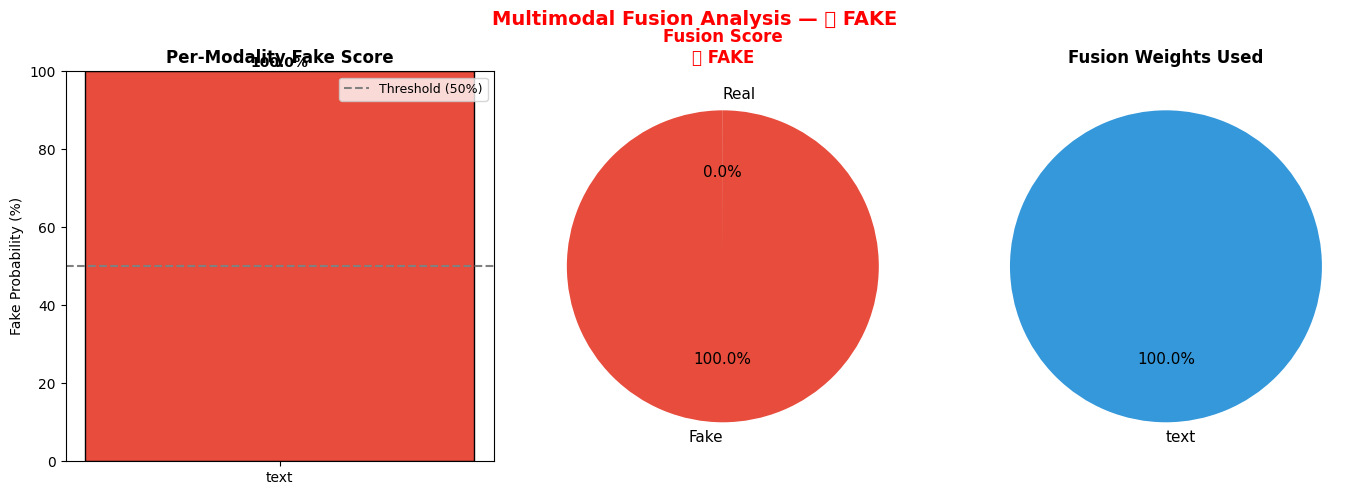


--- Real article test ---
   📝 Text  score : 4.1% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🟢 REAL
  Fake conf   : 4.1%
  Real conf   : 95.9%
  Modalities  : text
------------------------------------------------------------
  Individual scores:
  📝 text  : ░░░░░░░░░░░░░░░░░░░░ 4.1%


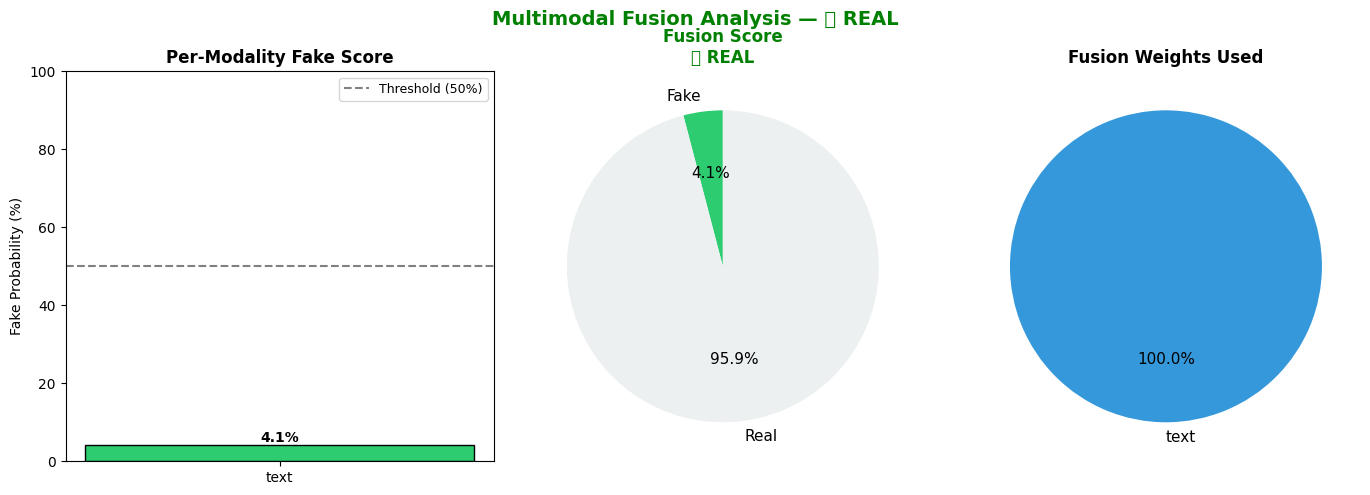

In [ ]:
print("TEST 1 — Text Only (BERT)\n")

fake_article = """
SHOCKING: Scientists have proven that 5G towers are being used
by the government to control citizens minds. Secret documents
leaked from the WHO confirm that COVID vaccines contain
microchips that activate when exposed to 5G signals.
Share this before it gets deleted!
"""

real_article = """
The Federal Reserve raised interest rates by 25 basis points
on Wednesday, as policymakers continued efforts to bring
inflation back to the central bank's 2 percent target.
The decision was unanimous among committee members.
"""

print("--- Fake article test ---")
result1 = multimodal_fusion(text=fake_article)
display_fusion_result(result1)

print("\n--- Real article test ---")
result2 = multimodal_fusion(text=real_article)
display_fusion_result(result2)

🧪 TEST 2 — Image Only (CNN)

📂 Upload an image to test (face photo / deepfake image)...


Saving a949303df9fca80e03c0affe7bbad12a.jpg to a949303df9fca80e03c0affe7bbad12a.jpg

✅ Uploaded: a949303df9fca80e03c0affe7bbad12a.jpg

Running fusion on image...
   🖼️  Image score : 0.1% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🟢 REAL
  Fake conf   : 0.1%
  Real conf   : 99.9%
  Modalities  : image
------------------------------------------------------------
  Individual scores:
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.1%


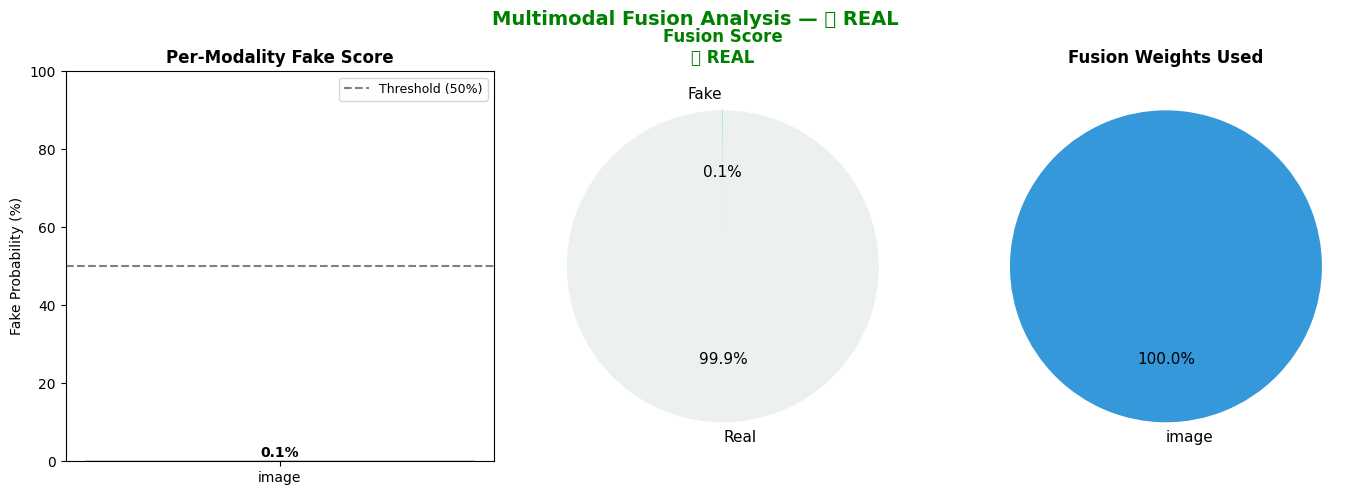

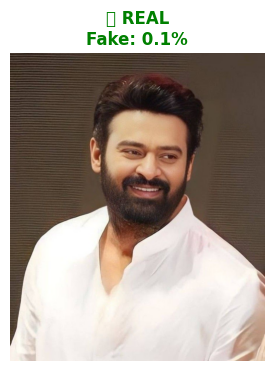

In [ ]:
from google.colab import files

print("🧪 TEST 2 — Image Only (CNN)\n")
print("📂 Upload an image to test (face photo / deepfake image)...")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {image_path}")
    print("\nRunning fusion on image...")
    result = multimodal_fusion(image_path=image_path)
    display_fusion_result(result, image_path=image_path)

    # Show the image
    img = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"{result['verdict']}\nFake: {result['confidence_fake']:.1f}%",
              fontweight='bold',
              color='red' if 'FAKE' in result['verdict'] else 'green')
    plt.axis('off')
    plt.show()

🧪 TEST 3 — Text + Image Combined

📂 Upload an image to combine with text...


Saving lord-rama-anjaneya-3840x4190-18958.jpg to lord-rama-anjaneya-3840x4190-18958 (1).jpg
Running multimodal fusion (text + image)...
   📝 Text  score : 100.0% fake
   🖼️  Image score : 8.5% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 60.8%
  Real conf   : 39.2%
  Modalities  : text, image
------------------------------------------------------------
  Individual scores:
  📝 text  : ████████████████████ 100.0%
  🖼️ image : █░░░░░░░░░░░░░░░░░░░ 8.5%


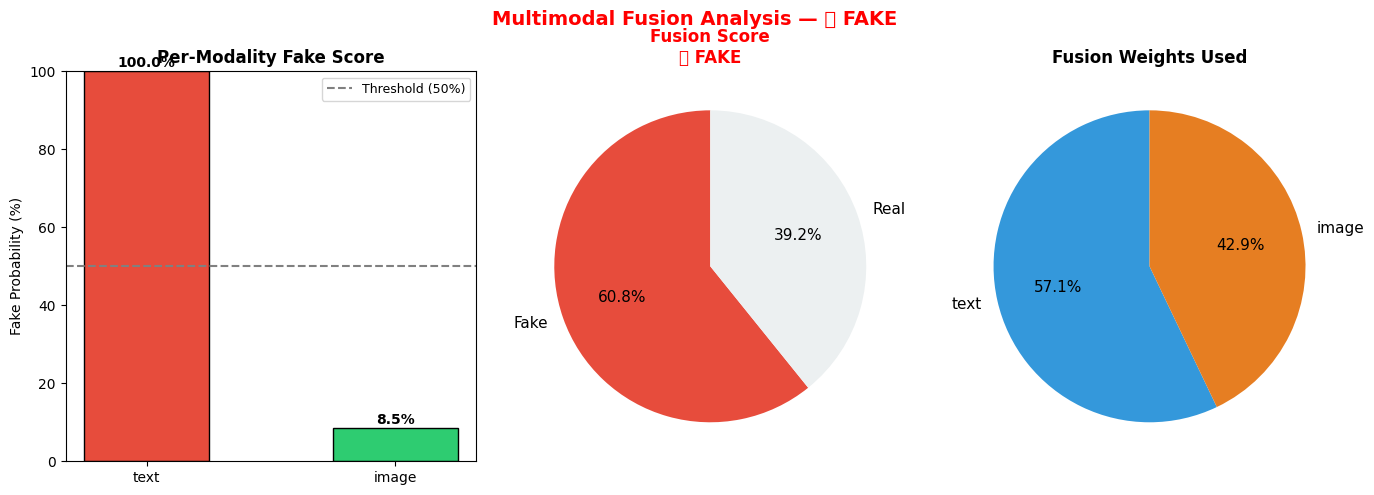


💡 Note how fusion combines both scores:
   Text alone would give: 100.0% fake
   Image alone would give: 8.54% fake
   Combined fusion score: 60.8% fake


In [ ]:
print("🧪 TEST 3 — Text + Image Combined\n")
print("📂 Upload an image to combine with text...")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    # Test with FAKE text + image
    fake_text = """
    Viral Image of Lord Hanuman Bowing Before Lord Rama Sparks Debate Online
    """

    print("Running multimodal fusion (text + image)...")
    result = multimodal_fusion(
        text=fake_text,
        image_path=image_path
    )
    display_fusion_result(result)

    print(f"\n💡 Note how fusion combines both scores:")
    print(f"   Text alone would give: "
          f"{result['individual_scores'].get('text', 'N/A')}% fake")
    print(f"   Image alone would give: "
          f"{result['individual_scores'].get('image', 'N/A')}% fake")
    print(f"   Combined fusion score: "
          f"{result['confidence_fake']:.1f}% fake")

🧪 TEST 4 — All Three Modalities

📂 Upload a video file...


Saving WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4 to WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4
📂 Upload an image file...


Saving WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg to WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg

🔍 Running full multimodal fusion...
   (text + image + video)
   📝 Text  score : 93.7% fake
   🖼️  Image score : 0.0% fake
   🎬 Video score : 0.0% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🟢 REAL
  Fake conf   : 37.5%
  Real conf   : 62.5%
  Modalities  : text, image, video
------------------------------------------------------------
  Individual scores:
  📝 text  : ██████████████████░░ 93.7%
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.0%
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 0.0%


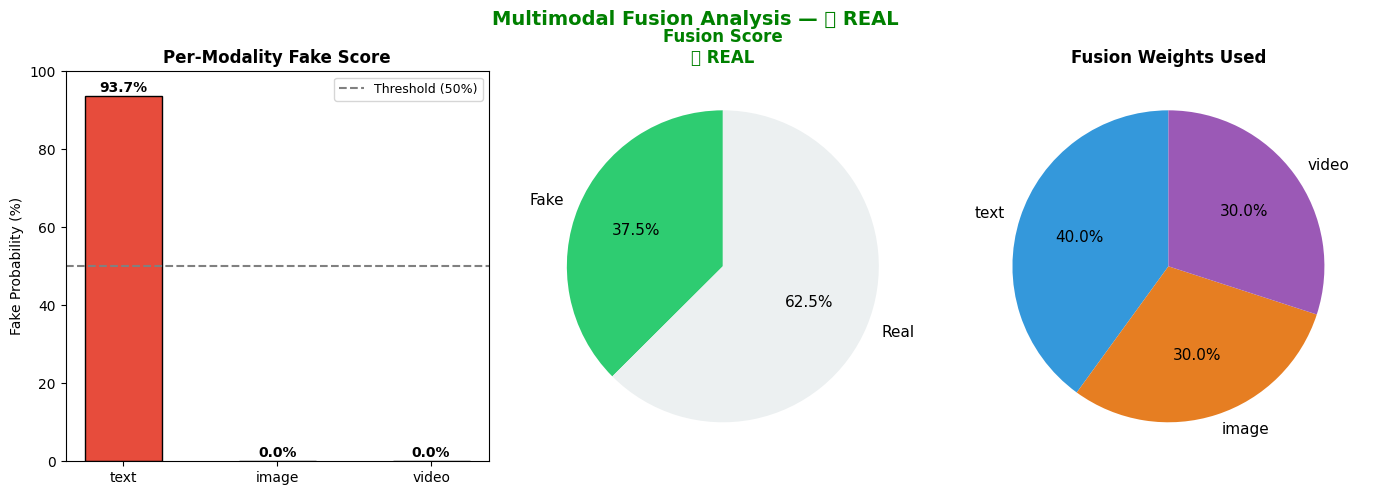

In [ ]:
print("🧪 TEST 4 — All Three Modalities\n")
print("📂 Upload a video file...")
uploaded_video = files.upload()

print("📂 Upload an image file...")
uploaded_image = files.upload()

if uploaded_video and uploaded_image:
    video_path = list(uploaded_video.keys())[0]
    image_path = list(uploaded_image.keys())[0]

    test_text = """
    Viral Video of Woman Appearing as Half-Human, Half-Serpent Stuns Social Media Users
    """

    print("\n🔍 Running full multimodal fusion...")
    print("   (text + image + video)")
    result = multimodal_fusion(
        text=test_text,
        image_path=image_path,
        video_path=video_path
    )
    display_fusion_result(result)

In [ ]:
import json

# Save fusion config
fusion_config = {
    "fusion_weights": {
        "text" : 0.4,
        "image": 0.3,
        "video": 0.3
    },
    "threshold"   : 0.5,
    "models": {
        "text" : "models/bert_model/",
        "image": "models/cnn_model/efficientnet_best.pth",
        "video": "models/cnn_model/efficientnet_video_finetuned.pth"
    },
    "individual_model_results": {
        "bert_accuracy"        : 99.13,
        "cnn_image_val_acc"    : 97.93,
        "cnn_video_accuracy"   : 99.89
    },
    "fusion_strategy": "Weighted average with auto-normalisation"
}

config_path = f"{FUSION_SAVE_PATH}/fusion_config.json"
with open(config_path, 'w') as f:
    json.dump(fusion_config, f, indent=4)

print("✅ Fusion config saved to Drive!")
print(f"   Location: {config_path}")
print(f"\n📊 Fusion System Summary:")
print(f"   BERT accuracy        : 99.13%")
print(f"   CNN image val acc    : 97.93%")
print(f"   CNN video accuracy   : 99.89%")
print(f"   Fusion weights       : Text 40% | Image 30% | Video 30%")
print(f"   Threshold            : 50%")
print(f"\n✅ Fusion module complete — ready for Streamlit!")

✅ Fusion config saved to Drive!
   Location: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/predictions/fusion_config.json

📊 Fusion System Summary:
   BERT accuracy        : 99.13%
   CNN image val acc    : 97.93%
   CNN video accuracy   : 99.89%
   Fusion weights       : Text 40% | Image 30% | Video 30%
   Threshold            : 50%

✅ Fusion module complete — ready for Streamlit!


In [ ]:
# ── Download CIFAKE dataset ──────────────────────────────────
import os
os.makedirs('/content/cifake_data', exist_ok=True)

print("⏳ Downloading CIFAKE dataset...")
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images \
    -p /content/cifake_data/
print("✅ Download complete!")

print("\n⏳ Unzipping...")
!unzip -q /content/cifake_data/*.zip -d /content/cifake_data/
print("✅ Done!")

# Check structure
print("\n📁 Folder structure:")
for root, dirs, files_list in os.walk('/content/cifake_data/'):
    level = root.replace('/content/cifake_data/', '').count(os.sep)
    if level <= 2:
        indent = '  ' * level
        images = [f for f in files_list
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"{indent}📂 {os.path.basename(root)}/  "
              f"({'%d images' % len(images) if images else ''})")

⏳ Downloading CIFAKE dataset...
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 117MB/s] 

✅ Download complete!

⏳ Unzipping...
✅ Done!

📁 Folder structure:
📂 /  ()
📂 test/  ()
  📂 REAL/  (10000 images)
  📂 FAKE/  (10000 images)
📂 train/  ()
  📂 REAL/  (50000 images)
  📂 FAKE/  (50000 images)


In [ ]:
# ── Load updated combined model ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, torch, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import transforms, models
from transformers import BertTokenizer, BertForSequenceClassification
from PIL import Image
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_PATH      = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
BERT_PATH      = os.path.join(BASE_PATH, "models/bert_model")
COMBINED_PATH  = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_combined_best.pth")
VIDEO_PATH     = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_video_finetuned.pth")

# ── Build EfficientNetB0 ─────────────────────────────────────
def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters():
        param.requires_grad = False
    for param in m.features[6:].parameters():
        param.requires_grad = True
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout/2),
        nn.Linear(512, num_classes)
    )
    return m

# ── Load all models ──────────────────────────────────────────
print("⏳ Loading all models...")

# BERT
!pip install -q transformers==4.35.0
bert_tokenizer = BertTokenizer.from_pretrained(BERT_PATH)
bert_model     = BertForSequenceClassification.from_pretrained(BERT_PATH)
bert_model     = bert_model.to(device)
bert_model.eval()
print("✅ BERT loaded!")

# Combined CNN (face deepfake + AI generated)
cnn_image_model = build_efficientnet()
w = torch.load(COMBINED_PATH, map_location=device)
cnn_image_model.load_state_dict(
    w['model_state'] if 'model_state' in w else w)
cnn_image_model = cnn_image_model.to(device)
cnn_image_model.eval()
print("✅ Combined CNN loaded! (face deepfake + AI generated)")

# Video CNN
cnn_video_model = build_efficientnet()
w = torch.load(VIDEO_PATH, map_location=device)
cnn_video_model.load_state_dict(
    w['model_state'] if 'model_state' in w else w)
cnn_video_model = cnn_video_model.to(device)
cnn_video_model.eval()
print("✅ Video CNN loaded!")

print(f"\n✅ All models ready on {device}!")

# ── Transform ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── Prediction functions ─────────────────────────────────────
def predict_text(text):
    bert_model.eval()
    enc = bert_tokenizer(
        text.lower().strip(), max_length=128,
        truncation=True, padding='max_length',
        return_tensors='pt')
    with torch.no_grad():
        probs = torch.softmax(
            bert_model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            ).logits, dim=1)
    return probs[0][1].item()   # index 1 = Fake

def predict_image(image_path):
    cnn_image_model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(cnn_image_model(tensor), dim=1)
    return probs[0][0].item()   # index 0 = Fake

def predict_video(video_path, num_frames=20):
    cap      = cv2.VideoCapture(video_path)
    total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    duration = total / fps if fps > 0 else 0
    if total == 0:
        cap.release()
        return None, 0
    indices    = np.linspace(0, total-1,
                             min(num_frames, total), dtype=int)
    fake_probs = []
    cnn_video_model.eval()
    with torch.no_grad():
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                img    = Image.fromarray(
                    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                tensor = transform(img).unsqueeze(0).to(device)
                probs  = torch.softmax(
                    cnn_video_model(tensor), dim=1)
                fake_probs.append(probs[0][0].item())
    cap.release()
    return (np.mean(fake_probs) if fake_probs else None), duration

# ── Master fusion function ───────────────────────────────────
def detect(text=None, image_path=None, video_path=None,
           text_weight=0.4, image_weight=0.3, video_weight=0.3):

    scores  = {}
    weights = {}

    print("\n🔍 Running Multimodal Fusion Detection...")
    print("=" * 55)

    if text and text.strip():
        s = predict_text(text)
        scores['text']  = s
        weights['text'] = text_weight
        print(f"   📝 Text  : {s*100:.1f}% fake")

    if image_path and os.path.exists(image_path):
        s = predict_image(image_path)
        scores['image']  = s
        weights['image'] = image_weight
        print(f"   🖼️  Image : {s*100:.1f}% fake")

        # Show image
        img = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image", fontsize=10)
        plt.show()

    if video_path and os.path.exists(video_path):
        s, duration = predict_video(video_path)
        if s is not None:
            scores['video']  = s
            weights['video'] = video_weight
            print(f"   🎬 Video : {s*100:.1f}% fake "
                  f"({duration:.1f}s)")

    if not scores:
        print("❌ No valid input!")
        return

    # Normalise weights
    total_w = sum(weights[k] for k in scores)
    norm_w  = {k: weights[k]/total_w for k in scores}

    # Weighted fusion
    fusion_score = sum(scores[k]*norm_w[k] for k in scores)
    conf_fake    = fusion_score * 100
    conf_real    = (1-fusion_score) * 100
    verdict      = "🔴 FAKE" if fusion_score >= 0.5 else "🟢 REAL"
    color        = 'red' if 'FAKE' in verdict else 'green'

    # ── Results ──────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  FINAL VERDICT : {verdict}")
    print(f"  Fake conf     : {conf_fake:.1f}%")
    print(f"  Real conf     : {conf_real:.1f}%")
    print(f"  Modalities    : {', '.join(scores.keys())}")
    print(f"{'='*55}")
    print("  Individual scores:")
    for mod, sc in scores.items():
        bar   = "█"*int(sc*20) + "░"*(20-int(sc*20))
        emoji = "📝" if mod=="text" else "🖼️" if mod=="image" else "🎬"
        print(f"  {emoji} {mod:<6}: {bar} {sc*100:.1f}%")
    print(f"{'='*55}")

    # ── Bar chart ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    mod_names  = list(scores.keys())
    mod_scores = [scores[k]*100 for k in mod_names]
    bar_colors = ['#e74c3c' if s>=50 else '#2ecc71'
                  for s in mod_scores]

    axes[0].bar(mod_names, mod_scores,
                color=bar_colors, edgecolor='black', width=0.4)
    axes[0].axhline(y=50, color='gray', linestyle='--',
                    linewidth=1.5, label='Threshold 50%')
    axes[0].set_ylim([0, 100])
    axes[0].set_title('Per-Modality Scores', fontweight='bold')
    axes[0].set_ylabel('Fake Probability (%)')
    axes[0].legend()
    for i, (name, score) in enumerate(zip(mod_names, mod_scores)):
        axes[0].text(i, score+1, f'{score:.1f}%',
                     ha='center', fontweight='bold')

    axes[1].pie([conf_fake, conf_real],
                labels=['Fake', 'Real'],
                colors=['#e74c3c' if conf_fake>=50 else '#ecf0f1',
                        '#2ecc71' if conf_real>50  else '#ecf0f1'],
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 12})
    axes[1].set_title(f'Fusion Result\n{verdict}',
                      fontweight='bold', color=color)

    plt.suptitle(f'Multimodal Fake Detection — {verdict}',
                 fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/outputs/graphs/fusion_final.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {"verdict": verdict,
            "fake_conf": round(conf_fake,2),
            "real_conf": round(conf_real,2),
            "scores"   : {k:round(v*100,2) for k,v in scores.items()}}

print("\n✅ detect() function ready!")
print("\n💡 Usage examples:")
print("   detect(text='your article here')")
print("   detect(image_path='photo.jpg')")
print("   detect(video_path='video.mp4')")
print("   detect(text='...', image_path='photo.jpg')")
print("   detect(text='...', image_path='photo.jpg', video_path='video.mp4')")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Loading all models...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BERT loaded!
✅ Combined CNN loaded! (face deepfake + AI generated)
✅ Video CNN loaded!

✅ All models ready on cuda!

✅ detect() function ready!

💡 Usage examples:
   detect(text='your article here')
   detect(image_path='photo.jpg')
   detect(video_path='video.mp4')
   detect(text='...', image_path='photo.jpg')
   detect(text='...', image_path='photo.jpg', video_path='video.mp4')



🔍 Running Multimodal Fusion Detection...
   📝 Text  : 100.0% fake

  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 100.0%
  Real conf     : 0.0%
  Modalities    : text
  Individual scores:
  📝 text  : ███████████████████░ 100.0%


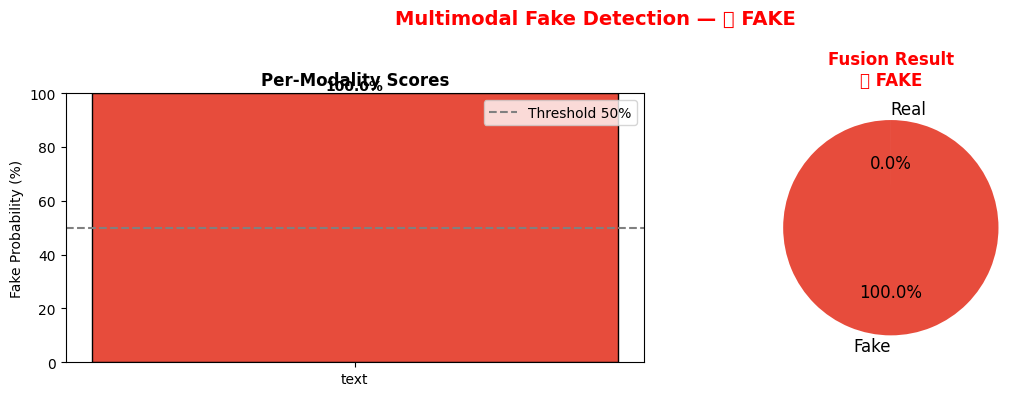


🔍 Running Multimodal Fusion Detection...
❌ No valid input!

🔍 Running Multimodal Fusion Detection...
❌ No valid input!

🔍 Running Multimodal Fusion Detection...
   📝 Text  : 100.0% fake

  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 100.0%
  Real conf     : 0.0%
  Modalities    : text
  Individual scores:
  📝 text  : ███████████████████░ 100.0%


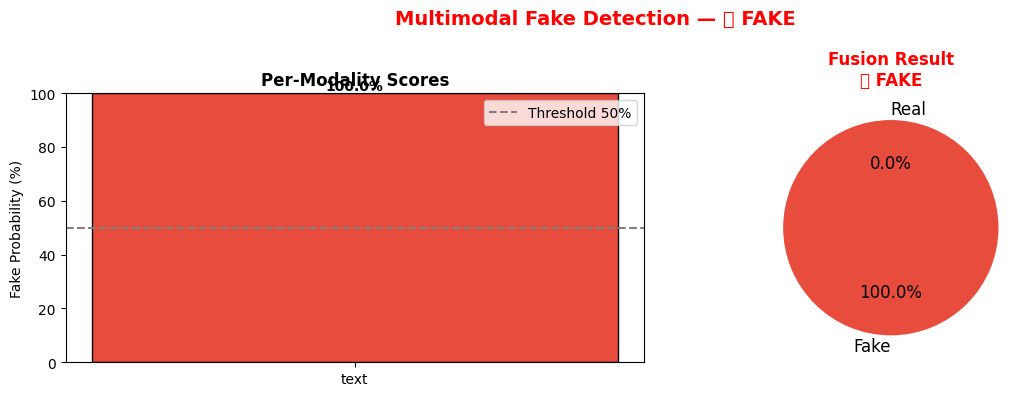


🔍 Running Multimodal Fusion Detection...
   📝 Text  : 100.0% fake

  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 100.0%
  Real conf     : 0.0%
  Modalities    : text
  Individual scores:
  📝 text  : ███████████████████░ 100.0%


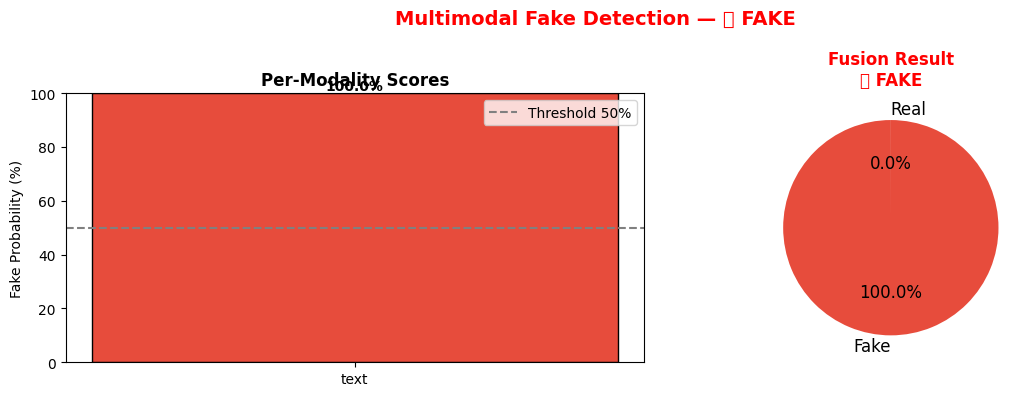

{'verdict': '🔴 FAKE',
 'fake_conf': 99.99,
 'real_conf': 0.01,
 'scores': {'text': 99.99}}

In [ ]:
# Text only
detect(text="Aliens have taken over the White House!")

# Image only
detect(image_path="/content/my_image.jpg")

# Video only
detect(video_path="/content/my_video.mp4")

# Text + Image
detect(
    text="Viral image of Lord Rama stuns social media",
    image_path="/content/rama_image.jpg"
)

# All three
detect(
    text="your headline here",
    image_path="/content/image.jpg",
    video_path="/content/video.mp4"
)

Saving WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg to WhatsApp Image 2026-05-29 at 12.42.55 PM (1).jpeg

🔍 Running Multimodal Fusion Detection...
   🖼️  Image : 0.9% fake


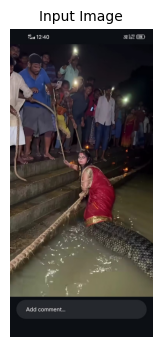


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 0.9%
  Real conf     : 99.1%
  Modalities    : image
  Individual scores:
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.9%


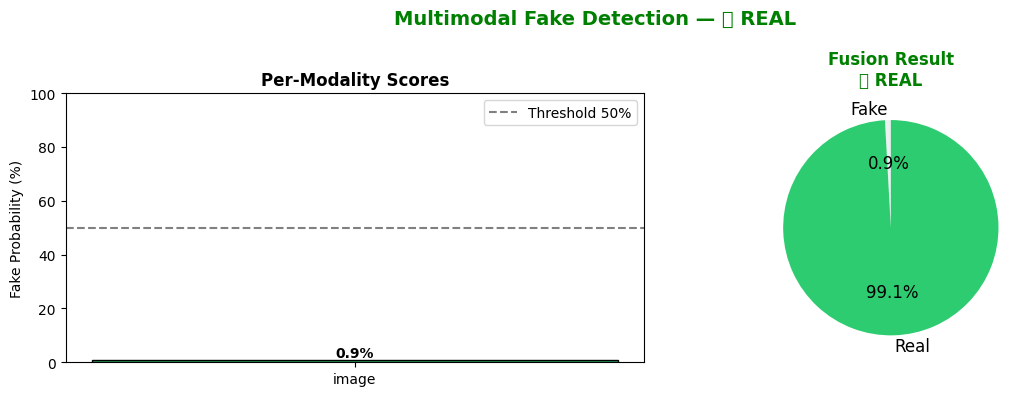

In [ ]:
from google.colab import files

# Upload any file
uploaded = files.upload()
fname    = list(uploaded.keys())[0]

# Auto detect file type
if fname.lower().endswith(('.jpg','.jpeg','.png')):
    detect(image_path=fname)
elif fname.lower().endswith(('.mp4','.avi','.mov')):
    detect(video_path=fname)
else:
    detect(text=open(fname).read())

📂 Upload IMAGE first...


Saving WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg to WhatsApp Image 2026-05-29 at 12.42.55 PM (3).jpeg
📂 Now upload VIDEO...


Saving WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4 to WhatsApp Video 2026-05-29 at 12.42.44 PM (3).mp4

🔍 Running Multimodal Fusion Detection...
   📝 Text  : 100.0% fake
   🖼️  Image : 0.9% fake


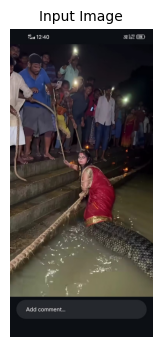

   🎬 Video : 0.0% fake (14.7s)

  FINAL VERDICT : 🟢 REAL
  Fake conf     : 40.3%
  Real conf     : 59.7%
  Modalities    : text, image, video
  Individual scores:
  📝 text  : ███████████████████░ 100.0%
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.9%
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 0.0%


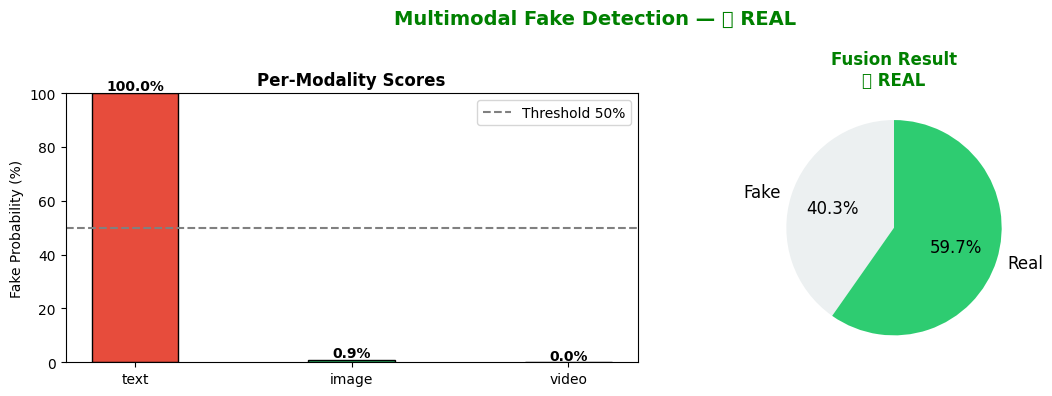

{'verdict': '🟢 REAL',
 'fake_conf': np.float64(40.26),
 'real_conf': np.float64(59.74),
 'scores': {'text': 100.0, 'image': 0.87, 'video': np.float64(0.0)}}

In [ ]:
from google.colab import files

print("📂 Upload IMAGE first...")
up1 = files.upload()
img_path = list(up1.keys())[0]

print("📂 Now upload VIDEO...")
up2 = files.upload()
vid_path = list(up2.keys())[0]

my_text = "Viral Video of Woman Appearing as Half-Human, Half-Serpent Stuns Social Media Users"

detect(text=my_text, image_path=img_path, video_path=vid_path)

📂 Upload image...


Saving lord-rama-anjaneya-3840x4190-18958.jpg to lord-rama-anjaneya-3840x4190-18958.jpg

🔍 Running Multimodal Fusion Detection...
   📝 Text  : 100.0% fake
   🖼️  Image : 74.1% fake


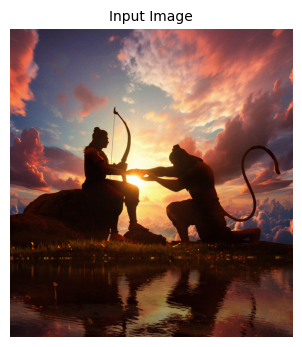


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 88.9%
  Real conf     : 11.1%
  Modalities    : text, image
  Individual scores:
  📝 text  : ███████████████████░ 100.0%
  🖼️ image : ██████████████░░░░░░ 74.1%


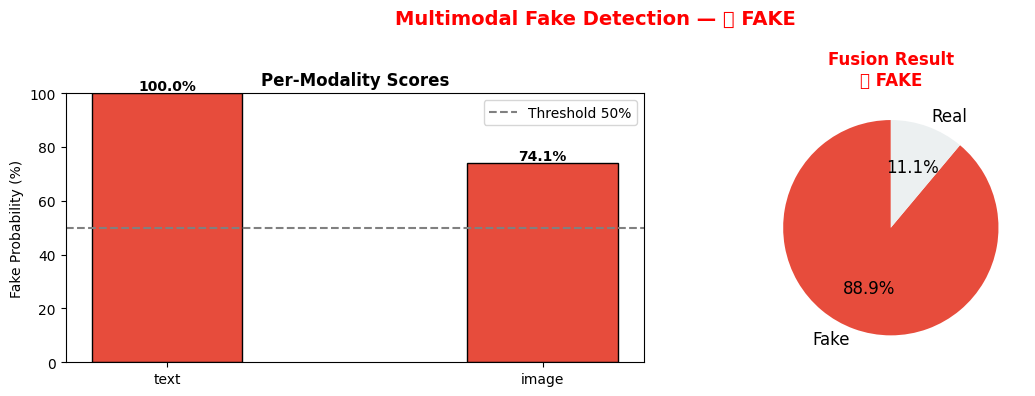

{'verdict': '🔴 FAKE',
 'fake_conf': 88.9,
 'real_conf': 11.1,
 'scores': {'text': 100.0, 'image': 74.1}}

In [ ]:
from google.colab import files

# Upload image
print("📂 Upload image...")
up1 = files.upload()
img_path = list(up1.keys())[0]

# Type your text
my_text = "Viral Image of Lord Rama stuns social media users worldwide"

detect(text=my_text, image_path=img_path)

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4 to WhatsApp Video 2026-06-27 at 3.47.21 PM (1).mp4

✅ Uploaded: WhatsApp Video 2026-06-27 at 3.47.21 PM (1).mp4
🎬 Detected: VIDEO


NameError: name 'detect' is not defined

code to load all models and video frames

In [ ]:
# ── Load updated combined model ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, torch, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import transforms, models
from transformers import BertTokenizer, BertForSequenceClassification
from PIL import Image
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_PATH      = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
BERT_PATH      = os.path.join(BASE_PATH, "models/bert_model")
COMBINED_PATH  = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_combined_best.pth")
VIDEO_PATH     = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_video_finetuned.pth")

# ── Build EfficientNetB0 ─────────────────────────────────────
def build_efficientnet(num_classes=2, dropout=0.3):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters():
        param.requires_grad = False
    for param in m.features[6:].parameters():
        param.requires_grad = True
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout/2),
        nn.Linear(512, num_classes)
    )
    return m

# ── Load all models ──────────────────────────────────────────
print("⏳ Loading all models...")

# BERT
!pip install -q transformers==4.35.0
bert_tokenizer = BertTokenizer.from_pretrained(BERT_PATH)
bert_model     = BertForSequenceClassification.from_pretrained(BERT_PATH)
bert_model     = bert_model.to(device)
bert_model.eval()
print("✅ BERT loaded!")

# Combined CNN (face deepfake + AI generated)
cnn_image_model = build_efficientnet()
w = torch.load(COMBINED_PATH, map_location=device)
cnn_image_model.load_state_dict(
    w['model_state'] if 'model_state' in w else w)
cnn_image_model = cnn_image_model.to(device)
cnn_image_model.eval()
print("✅ Combined CNN loaded! (face deepfake + AI generated)")

# Video CNN
cnn_video_model = build_efficientnet()
w = torch.load(VIDEO_PATH, map_location=device)
cnn_video_model.load_state_dict(
    w['model_state'] if 'model_state' in w else w)
cnn_video_model = cnn_video_model.to(device)
cnn_video_model.eval()
print("✅ Video CNN loaded!")

print(f"\n✅ All models ready on {device}!")

# ── Transform ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── Prediction functions ─────────────────────────────────────
def predict_text(text):
    bert_model.eval()
    enc = bert_tokenizer(
        text.lower().strip(), max_length=128,
        truncation=True, padding='max_length',
        return_tensors='pt')
    with torch.no_grad():
        probs = torch.softmax(
            bert_model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            ).logits, dim=1)
    return probs[0][1].item()   # index 1 = Fake

def predict_image(image_path):
    cnn_image_model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(cnn_image_model(tensor), dim=1)
    return probs[0][0].item()   # index 0 = Fake

def predict_video(video_path, num_frames=20):
    cap      = cv2.VideoCapture(video_path)
    total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    duration = total / fps if fps > 0 else 0
    if total == 0:
        cap.release()
        return None, 0
    indices    = np.linspace(0, total-1,
                             min(num_frames, total), dtype=int)
    fake_probs = []
    cnn_video_model.eval()
    with torch.no_grad():
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                img    = Image.fromarray(
                    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                tensor = transform(img).unsqueeze(0).to(device)
                probs  = torch.softmax(
                    cnn_video_model(tensor), dim=1)
                fake_probs.append(probs[0][0].item())
    cap.release()
    return (np.mean(fake_probs) if fake_probs else None), duration

# ── Master fusion function ───────────────────────────────────
def show_video_frames(video_path, num_frames=4):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        min(num_frames, total_frames),
        dtype=int
    )

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()

    plt.figure(figsize=(14,4))

    for i, frame in enumerate(frames):
        plt.subplot(1, len(frames), i + 1)
        plt.imshow(frame)
        plt.axis('off')
        plt.title(f'Frame {i+1}')

    plt.suptitle("Video Sample Frames", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
def detect(text=None, image_path=None, video_path=None,
           text_weight=0.4, image_weight=0.3, video_weight=0.3):

    scores  = {}
    weights = {}

    print("\n🔍 Running Multimodal Fusion Detection...")
    print("=" * 55)

    if text and text.strip():
        s = predict_text(text)
        scores['text']  = s
        weights['text'] = text_weight
        print(f"   📝 Text  : {s*100:.1f}% fake")

    if image_path and os.path.exists(image_path):
        s = predict_image(image_path)
        scores['image']  = s
        weights['image'] = image_weight
        print(f"   🖼️  Image : {s*100:.1f}% fake")

        # Show image
        img = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image", fontsize=10)
        plt.show()

    if video_path and os.path.exists(video_path):
      s, duration = predict_video(video_path)

      if s is not None:
        scores['video'] = s
        weights['video'] = video_weight

        print(f"   🎬 Video : {s*100:.1f}% fake "
              f"({duration:.1f}s)")

        # Show 4 frames from video
        show_video_frames(video_path, num_frames=4)

    if not scores:
        print("❌ No valid input!")
        return

    # Normalise weights
    total_w = sum(weights[k] for k in scores)
    norm_w  = {k: weights[k]/total_w for k in scores}

    # Weighted fusion
    fusion_score = sum(scores[k]*norm_w[k] for k in scores)
    conf_fake    = fusion_score * 100
    conf_real    = (1-fusion_score) * 100
    verdict      = "🔴 FAKE" if fusion_score >= 0.5 else "🟢 REAL"
    color        = 'red' if 'FAKE' in verdict else 'green'

    # ── Results ──────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  FINAL VERDICT : {verdict}")
    print(f"  Fake conf     : {conf_fake:.1f}%")
    print(f"  Real conf     : {conf_real:.1f}%")
    print(f"  Modalities    : {', '.join(scores.keys())}")
    print(f"{'='*55}")
    print("  Individual scores:")
    for mod, sc in scores.items():
        bar   = "█"*int(sc*20) + "░"*(20-int(sc*20))
        emoji = "📝" if mod=="text" else "🖼️" if mod=="image" else "🎬"
        print(f"  {emoji} {mod:<6}: {bar} {sc*100:.1f}%")
    print(f"{'='*55}")

    # ── Bar chart ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    mod_names  = list(scores.keys())
    mod_scores = [scores[k]*100 for k in mod_names]
    bar_colors = ['#e74c3c' if s>=50 else '#2ecc71'
                  for s in mod_scores]

    axes[0].bar(mod_names, mod_scores,
                color=bar_colors, edgecolor='black', width=0.4)
    axes[0].axhline(y=50, color='gray', linestyle='--',
                    linewidth=1.5, label='Threshold 50%')
    axes[0].set_ylim([0, 100])
    axes[0].set_title('Per-Modality Scores', fontweight='bold')
    axes[0].set_ylabel('Fake Probability (%)')
    axes[0].legend()
    for i, (name, score) in enumerate(zip(mod_names, mod_scores)):
        axes[0].text(i, score+1, f'{score:.1f}%',
                     ha='center', fontweight='bold')

    axes[1].pie([conf_fake, conf_real],
                labels=['Fake', 'Real'],
                colors=['#e74c3c' if conf_fake>=50 else '#ecf0f1',
                        '#2ecc71' if conf_real>50  else '#ecf0f1'],
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 12})
    axes[1].set_title(f'Fusion Result\n{verdict}',
                      fontweight='bold', color=color)

    plt.suptitle(f'Multimodal Fake Detection — {verdict}',
                 fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/outputs/graphs/fusion_final.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {"verdict": verdict,
            "fake_conf": round(conf_fake,2),
            "real_conf": round(conf_real,2),
            "scores"   : {k:round(v*100,2) for k,v in scores.items()}}

print("\n✅ detect() function ready!")
print("\n💡 Usage examples:")
print("   detect(text='your article here')")
print("   detect(image_path='photo.jpg')")
print("   detect(video_path='video.mp4')")
print("   detect(text='...', image_path='photo.jpg')")
print("   detect(text='...', image_path='photo.jpg', video_path='video.mp4')")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Loading all models...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BERT loaded!
✅ Combined CNN loaded! (face deepfake + AI generated)
✅ Video CNN loaded!

✅ All models ready on cuda!

✅ detect() function ready!

💡 Usage examples:
   detect(text='your article here')
   detect(image_path='photo.jpg')
   detect(video_path='video.mp4')
   detect(text='...', image_path='photo.jpg')
   detect(text='...', image_path='photo.jpg', video_path='video.mp4')


📂 Upload IMAGE first...


Saving WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg to WhatsApp Image 2026-05-29 at 12.42.55 PM (4).jpeg
📂 Now upload VIDEO...


Saving WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4 to WhatsApp Video 2026-05-29 at 12.42.44 PM (4).mp4

🔍 Running Multimodal Fusion Detection...
   📝 Text  : 100.0% fake
   🖼️  Image : 0.9% fake


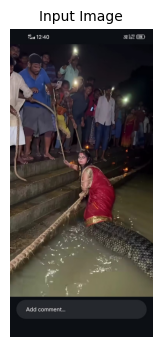

   🎬 Video : 0.0% fake (14.7s)


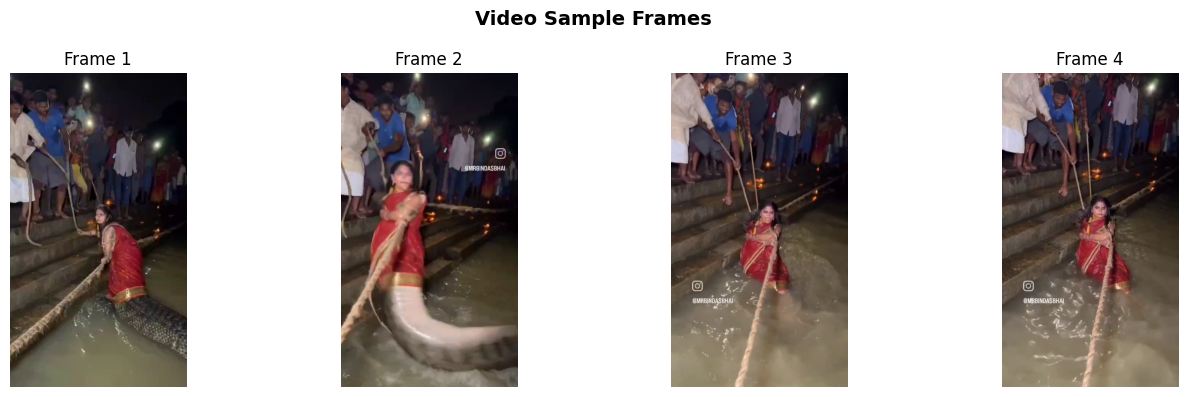


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 40.3%
  Real conf     : 59.7%
  Modalities    : text, image, video
  Individual scores:
  📝 text  : ███████████████████░ 100.0%
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.9%
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 0.0%


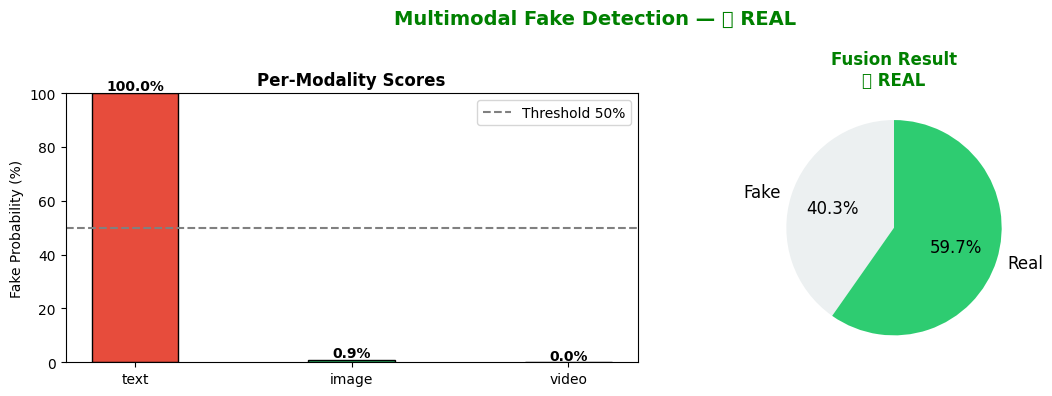

{'verdict': '🟢 REAL',
 'fake_conf': np.float64(40.26),
 'real_conf': np.float64(59.74),
 'scores': {'text': 100.0, 'image': 0.87, 'video': np.float64(0.0)}}

In [ ]:
from google.colab import files

print("📂 Upload IMAGE first...")
up1 = files.upload()
img_path = list(up1.keys())[0]

print("📂 Now upload VIDEO...")
up2 = files.upload()
vid_path = list(up2.keys())[0]

my_text = "Viral Video of Woman Appearing as Half-Human, Half-Serpent Stuns Social Media Users"

detect(text=my_text, image_path=img_path, video_path=vid_path)

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WIN_20260601_20_40_18_Pro.mp4 to WIN_20260601_20_40_18_Pro.mp4

✅ Uploaded: WIN_20260601_20_40_18_Pro.mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 90.8% fake (8.5s)


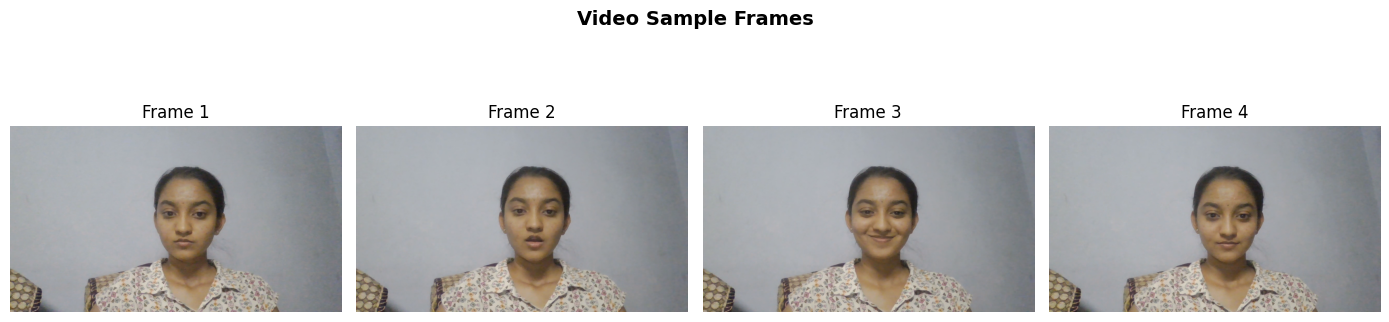


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 90.8%
  Real conf     : 9.2%
  Modalities    : video
  Individual scores:
  🎬 video : ██████████████████░░ 90.8%


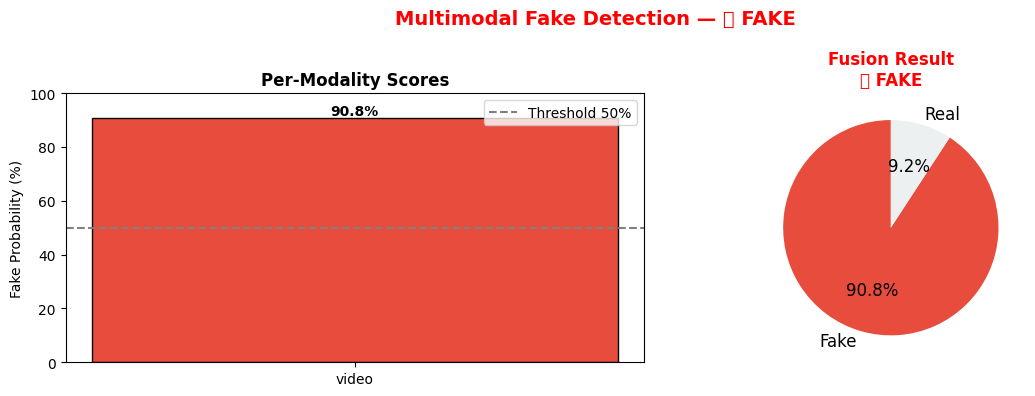

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4 to WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4

✅ Uploaded: WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4
🎬 Detected: VIDEO


NameError: name 'detect' is not defined

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving 24298.jpg to 24298.jpg

✅ Uploaded: 24298.jpg
🖼️  Detected: IMAGE

🔍 Running Multimodal Fusion Detection...
   🖼️  Image : 95.5% fake


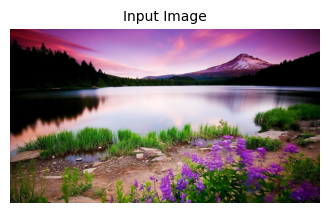


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 95.5%
  Real conf     : 4.5%
  Modalities    : image
  Individual scores:
  🖼️ image : ███████████████████░ 95.5%


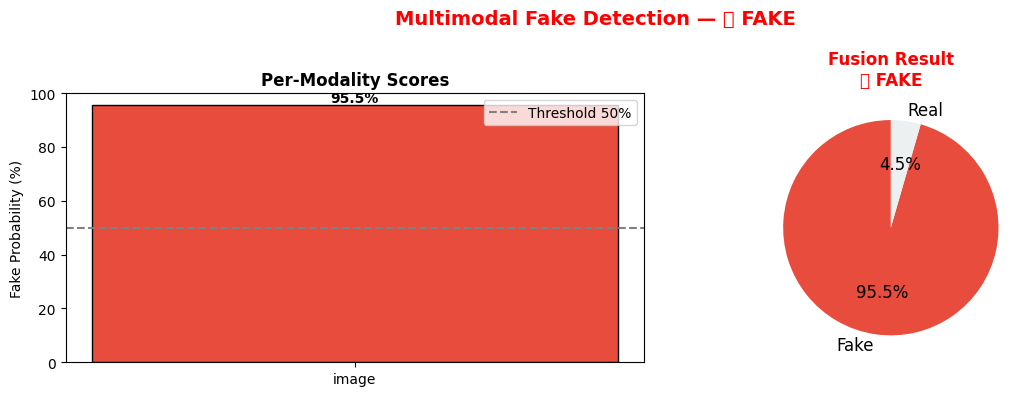

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving Screenshot 2026-06-01 210321.png to Screenshot 2026-06-01 210321.png

✅ Uploaded: Screenshot 2026-06-01 210321.png
🖼️  Detected: IMAGE

🔍 Running Multimodal Fusion Detection...
   🖼️  Image : 98.7% fake


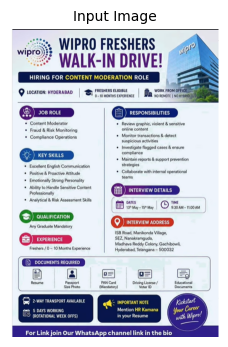


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 98.7%
  Real conf     : 1.3%
  Modalities    : image
  Individual scores:
  🖼️ image : ███████████████████░ 98.7%


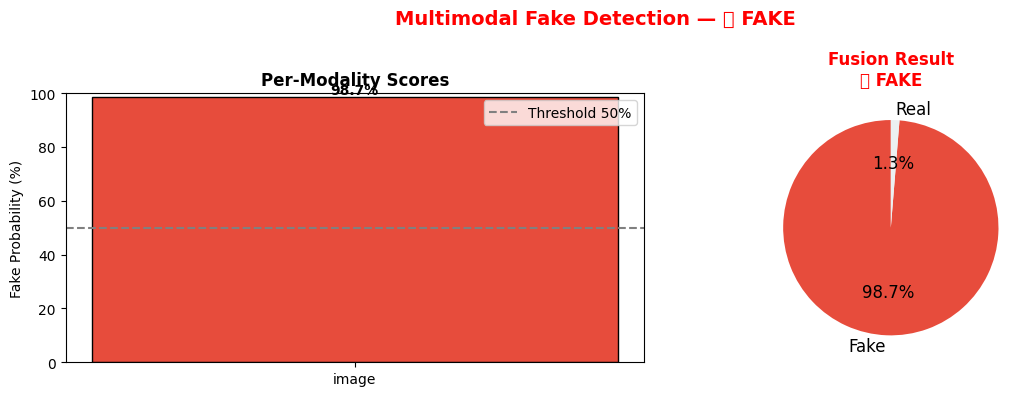

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WIN_20260601_20_40_18_Pro.mp4 to WIN_20260601_20_40_18_Pro (1).mp4

✅ Uploaded: WIN_20260601_20_40_18_Pro (1).mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 90.8% fake (8.5s)


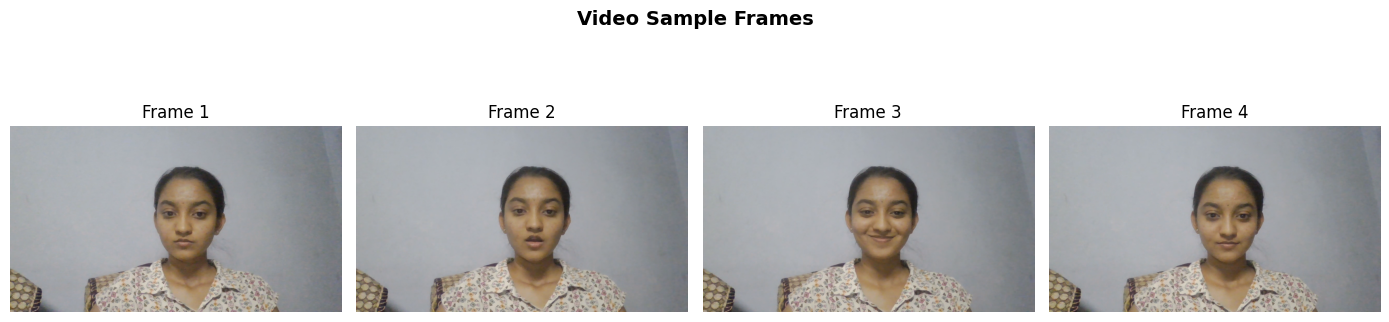


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 90.8%
  Real conf     : 9.2%
  Modalities    : video
  Individual scores:
  🎬 video : ██████████████████░░ 90.8%


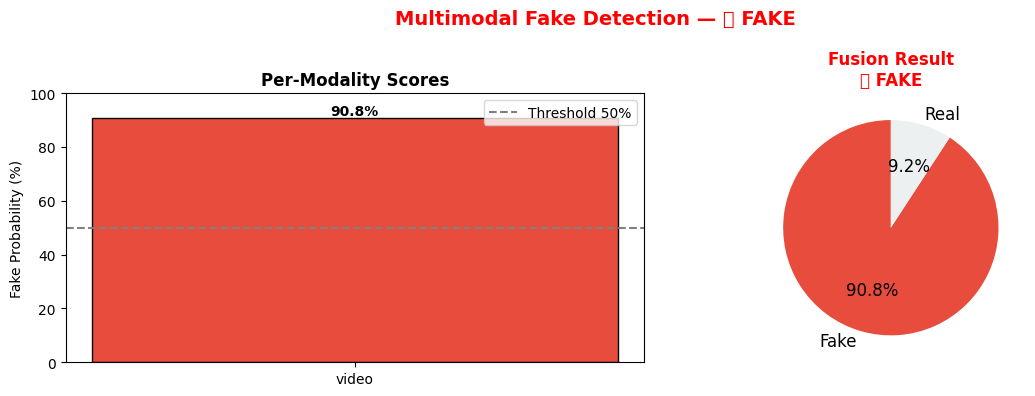

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

In [ ]:
# ── Fix: Reload correct video model ─────────────────────────
VIDEO_CORRECT_PATH = os.path.join(
    BASE_PATH,
    "models/cnn_model/efficientnet_video_finetuned.pth")

print("🔄 Reloading original video model...")
cnn_video_model = build_efficientnet()
w = torch.load(VIDEO_CORRECT_PATH, map_location=device)
cnn_video_model.load_state_dict(
    w['model_state'] if 'model_state' in w else w)
cnn_video_model = cnn_video_model.to(device)
cnn_video_model.eval()
print("✅ Original video model restored!")
print(f"   Path: {VIDEO_CORRECT_PATH}")
print("\n📊 Model summary:")
print("   📝 Text  → BERT (99.13%)")
print("   🖼️  Image → Combined CNN (97.72%) face + AI generated")
print("   🎬 Video → Original video model (99.89%) face videos")

🔄 Reloading original video model...
✅ Original video model restored!
   Path: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/cnn_model/efficientnet_video_finetuned.pth

📊 Model summary:
   📝 Text  → BERT (99.13%)
   🖼️  Image → Combined CNN (97.72%) face + AI generated
   🎬 Video → Original video model (99.89%) face videos


📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WIN_20260601_20_40_18_Pro.mp4 to WIN_20260601_20_40_18_Pro (2).mp4

✅ Uploaded: WIN_20260601_20_40_18_Pro (2).mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 90.8% fake (8.5s)


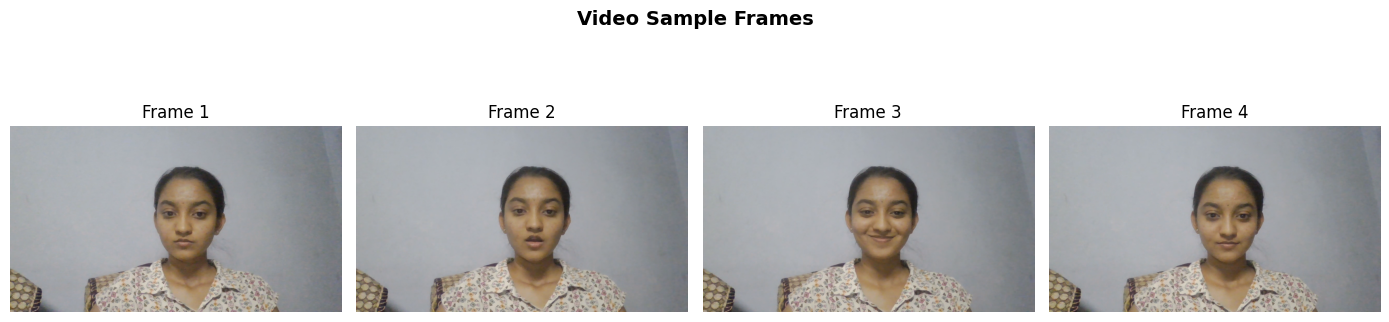


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 90.8%
  Real conf     : 9.2%
  Modalities    : video
  Individual scores:
  🎬 video : ██████████████████░░ 90.8%


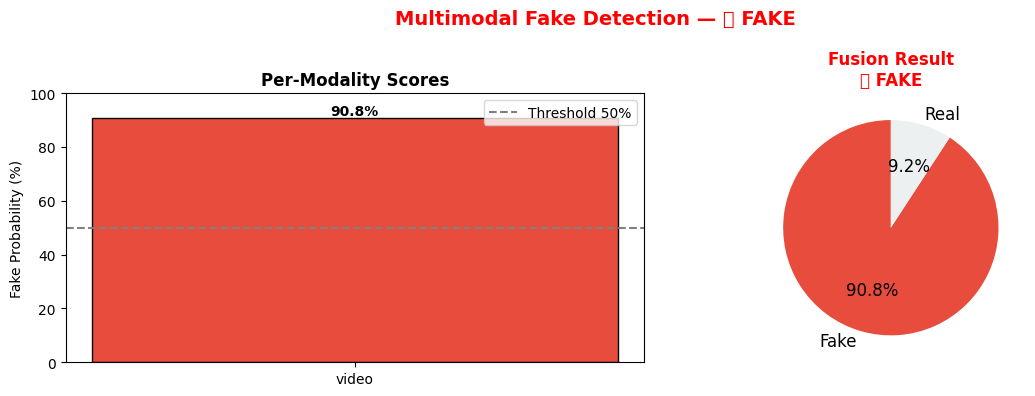

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

In [ ]:
# ── Diagnosis cell ───────────────────────────────────────────
from google.colab import files
import torch
import numpy as np
from PIL import Image
import cv2

print("📂 Upload YOUR face video...")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# Extract frames and check per-frame scores
cap     = cv2.VideoCapture(video_path)
total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps     = cap.get(cv2.CAP_PROP_FPS)
indices = np.linspace(0, total-1, min(10, total), dtype=int)

print(f"\n📊 Video info:")
print(f"   Total frames : {total}")
print(f"   FPS          : {fps:.1f}")
print(f"   Duration     : {total/fps:.1f}s")
print(f"\n🔍 Per-frame fake probability:")
print("-" * 40)

fake_probs = []
for i, idx in enumerate(indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        img    = Image.fromarray(
            cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        tensor = transform(img).unsqueeze(0).to(device)

        # Test on BOTH models
        with torch.no_grad():
            p_video    = torch.softmax(
                cnn_video_model(tensor), dim=1)
            p_combined = torch.softmax(
                cnn_image_model(tensor), dim=1)

        fv = p_video[0][0].item() * 100
        fc = p_combined[0][0].item() * 100
        fake_probs.append(fv)

        print(f"   Frame {i+1:>2}: "
              f"Video model={fv:.1f}%  "
              f"Combined model={fc:.1f}%")

cap.release()
print("-" * 40)
print(f"   Avg video model    : {np.mean(fake_probs):.1f}%")
print(f"\n✅ If video model > 50% on YOUR real face")
print(f"   → video model is still biased from CIFAKE")
print(f"   → Solution: use combined model for video too")

📂 Upload YOUR face video...


Saving WIN_20260601_20_40_18_Pro.mp4 to WIN_20260601_20_40_18_Pro.mp4

📊 Video info:
   Total frames : 128
   FPS          : 15.0
   Duration     : 8.5s

🔍 Per-frame fake probability:
----------------------------------------
   Frame  1: Video model=38.5%  Combined model=0.0%
   Frame  2: Video model=53.6%  Combined model=0.1%
   Frame  3: Video model=99.0%  Combined model=0.0%
   Frame  4: Video model=98.6%  Combined model=0.0%
   Frame  5: Video model=98.5%  Combined model=0.0%
   Frame  6: Video model=58.9%  Combined model=0.0%
   Frame  7: Video model=94.4%  Combined model=0.0%
   Frame  8: Video model=97.7%  Combined model=0.0%
   Frame  9: Video model=55.2%  Combined model=0.0%
   Frame 10: Video model=94.3%  Combined model=0.0%
----------------------------------------
   Avg video model    : 78.9%

✅ If video model > 50% on YOUR real face
   → video model is still biased from CIFAKE
   → Solution: use combined model for video too


In [ ]:
# ── Use combined model for BOTH image and video ──────────────
print("🔄 Switching video to use combined model...")
cnn_video_model = cnn_image_model  # same model for both!
print("✅ Fixed!")
print("\n📊 Final model setup:")
print("   📝 Text  → BERT                (99.13%)")
print("   🖼️  Image → Combined CNN        (97.72%)")
print("   🎬 Video → Combined CNN        (97.72%)")

🔄 Switching video to use combined model...
✅ Fixed!

📊 Final model setup:
   📝 Text  → BERT                (99.13%)
   🖼️  Image → Combined CNN        (97.72%)
   🎬 Video → Combined CNN        (97.72%)



🔍 Running Multimodal Fusion Detection...
   🎬 Video : 0.0% fake (8.5s)


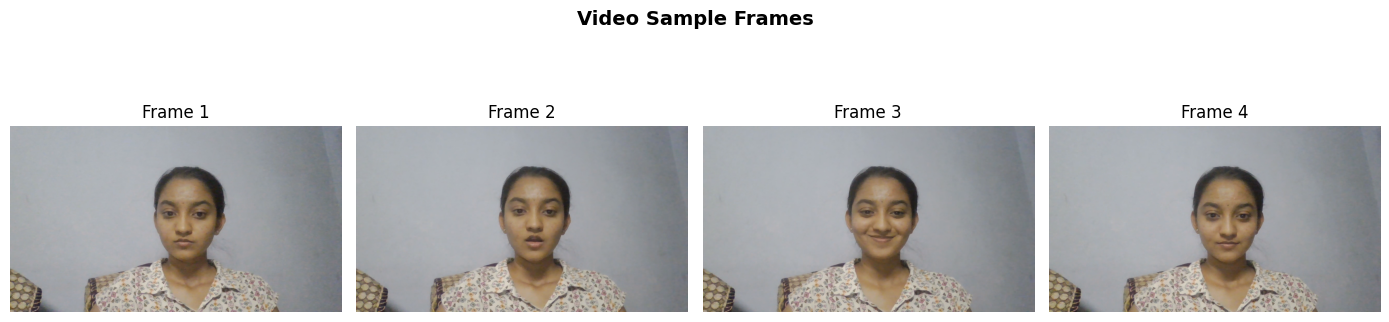


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 0.0%
  Real conf     : 100.0%
  Modalities    : video
  Individual scores:
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 0.0%


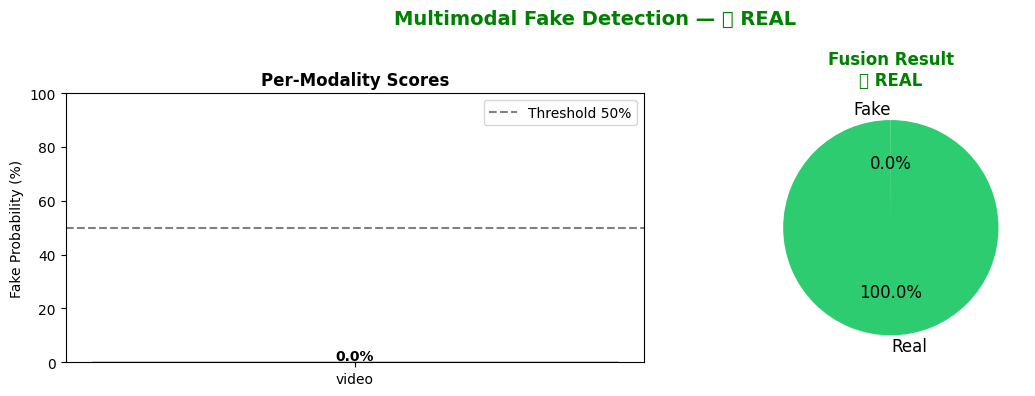

{'verdict': '🟢 REAL',
 'fake_conf': np.float64(0.03),
 'real_conf': np.float64(99.97),
 'scores': {'video': np.float64(0.03)}}

In [ ]:
detect(video_path="WIN_20260601_20_40_18_Pro.mp4")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4 to WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4

✅ Uploaded: WhatsApp Video 2026-05-29 at 12.42.44 PM.mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 1.5% fake (14.7s)


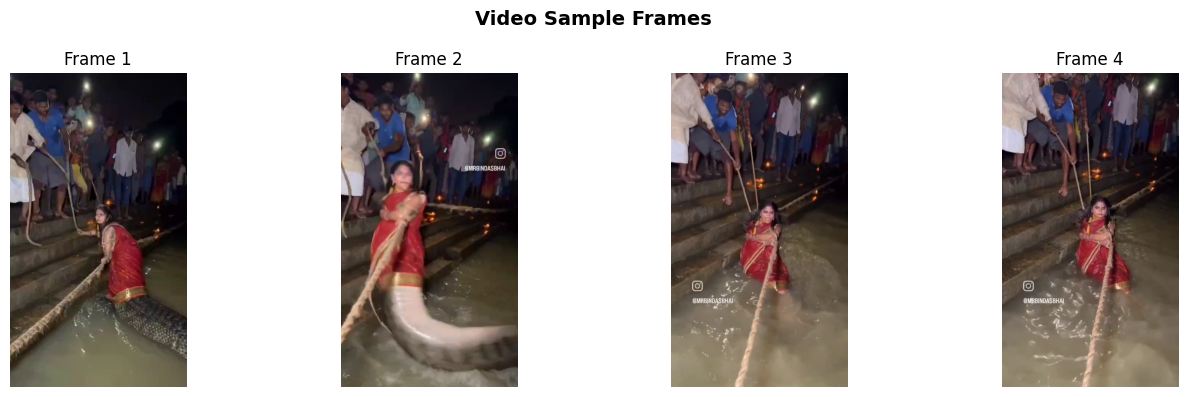


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 1.5%
  Real conf     : 98.5%
  Modalities    : video
  Individual scores:
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 1.5%


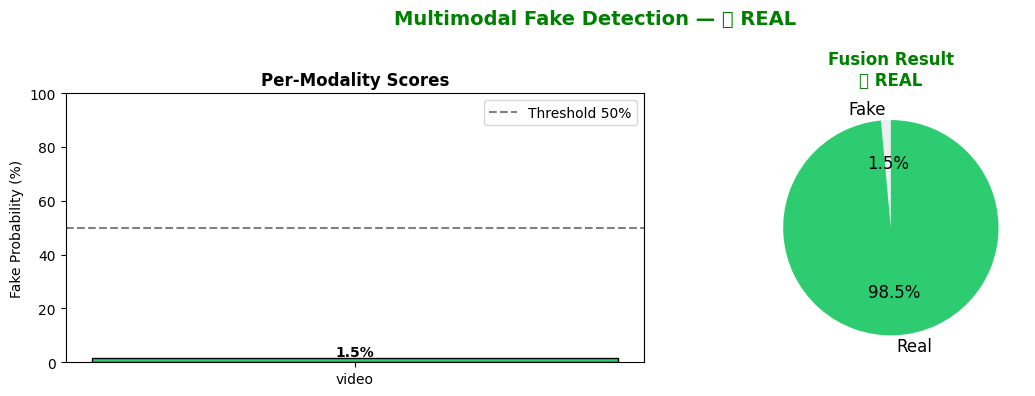

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving VID_20260601_081518_964.mp4 to VID_20260601_081518_964.mp4

✅ Uploaded: VID_20260601_081518_964.mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 65.0% fake (48.0s)


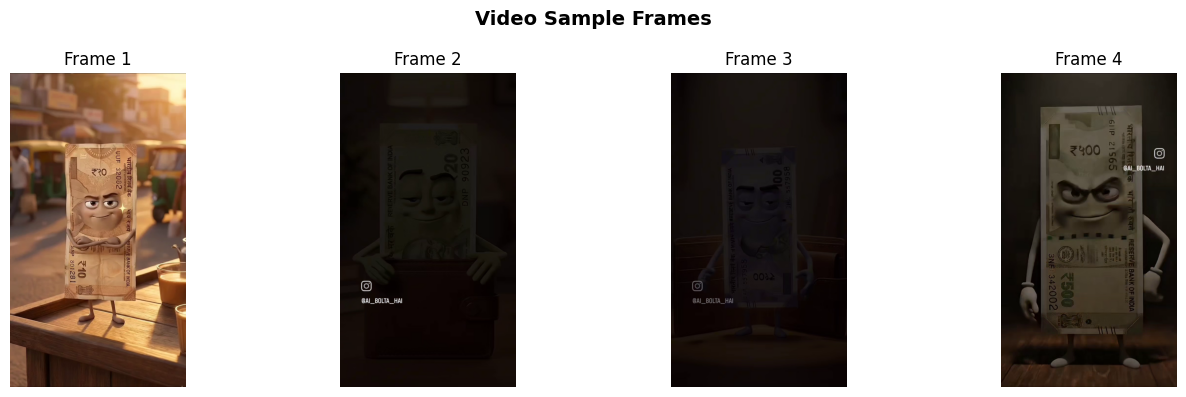


  FINAL VERDICT : 🔴 FAKE
  Fake conf     : 65.0%
  Real conf     : 35.0%
  Modalities    : video
  Individual scores:
  🎬 video : █████████████░░░░░░░ 65.0%


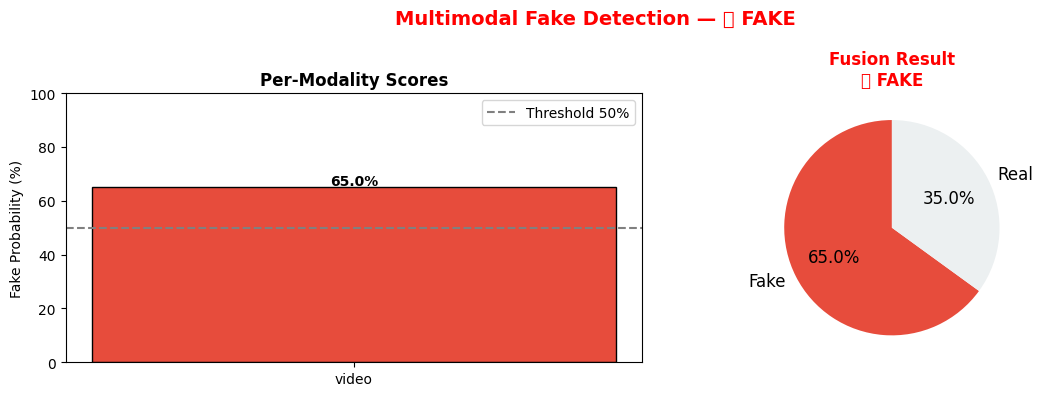

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg to WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg

✅ Uploaded: WhatsApp Image 2026-05-29 at 12.42.55 PM.jpeg
🖼️  Detected: IMAGE

🔍 Running Multimodal Fusion Detection...
   🖼️  Image : 0.9% fake


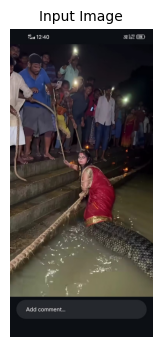


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 0.9%
  Real conf     : 99.1%
  Modalities    : image
  Individual scores:
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.9%


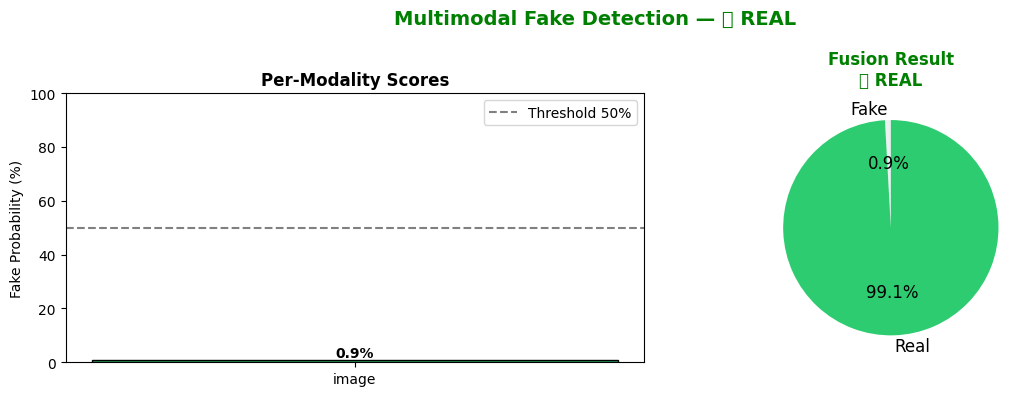

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving (3) Why Developers Waste 30% of Their Time (and How Planto.ai Fixes It) - YouTube - Google Chrome 2026-06-02 17-39-54.mp4 to (3) Why Developers Waste 30% of Their Time (and How Planto.ai Fixes It) - YouTube - Google Chrome 2026-06-02 17-39-54.mp4

✅ Uploaded: (3) Why Developers Waste 30% of Their Time (and How Planto.ai Fixes It) - YouTube - Google Chrome 2026-06-02 17-39-54.mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 9.0% fake (13.7s)


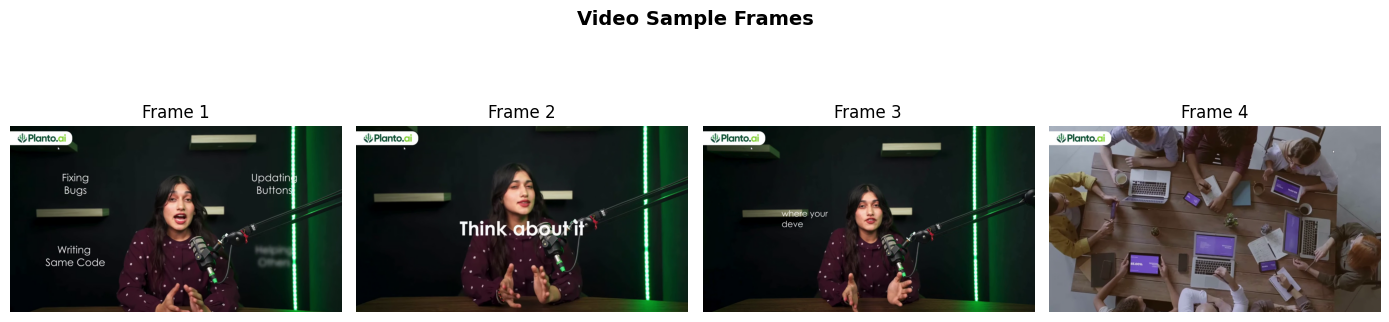


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 9.0%
  Real conf     : 91.0%
  Modalities    : video
  Individual scores:
  🎬 video : █░░░░░░░░░░░░░░░░░░░ 9.0%


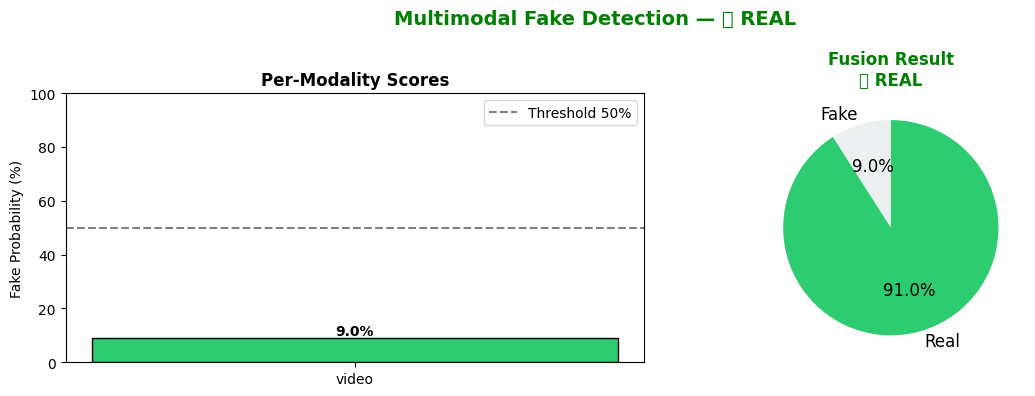

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving (3) Andy_ A Dog's Tale _ Full Film _ Canine Companions #animation #puppy #servicedog - YouTube - Google Chrome 2026-06-02 17-44-01.mp4 to (3) Andy_ A Dog's Tale _ Full Film _ Canine Companions #animation #puppy #servicedog - YouTube - Google Chrome 2026-06-02 17-44-01.mp4

✅ Uploaded: (3) Andy_ A Dog's Tale _ Full Film _ Canine Companions #animation #puppy #servicedog - YouTube - Google Chrome 2026-06-02 17-44-01.mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 23.7% fake (13.3s)


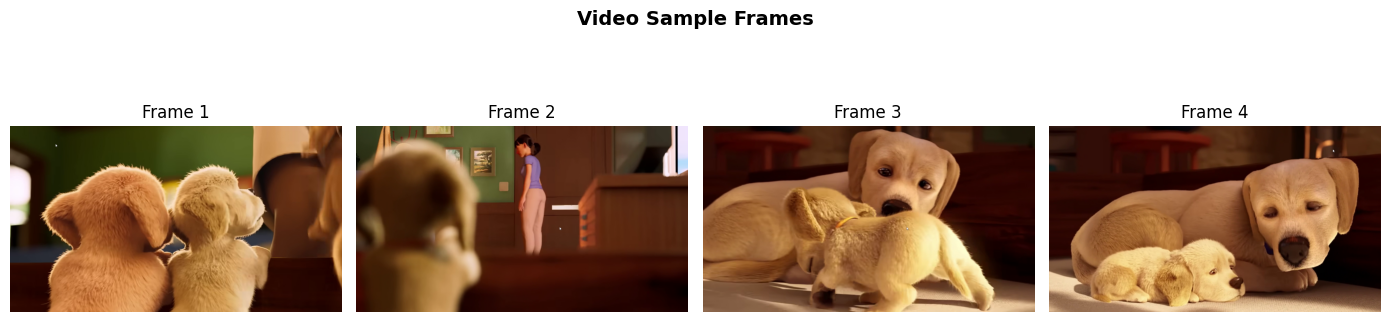


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 23.7%
  Real conf     : 76.3%
  Modalities    : video
  Individual scores:
  🎬 video : ████░░░░░░░░░░░░░░░░ 23.7%


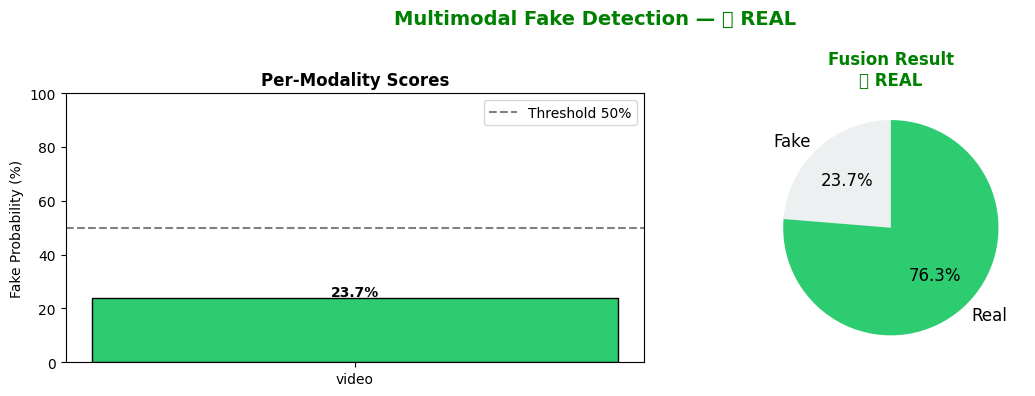

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

📂 Upload any file — image, video, or text file
   Or skip and type text directly below


Saving (3) How to swap your face with AI for free #shorts - YouTube - Google Chrome 2026-06-02 17-53-16.mp4 to (3) How to swap your face with AI for free #shorts - YouTube - Google Chrome 2026-06-02 17-53-16.mp4

✅ Uploaded: (3) How to swap your face with AI for free #shorts - YouTube - Google Chrome 2026-06-02 17-53-16.mp4
🎬 Detected: VIDEO

🔍 Running Multimodal Fusion Detection...
   🎬 Video : 0.5% fake (12.9s)


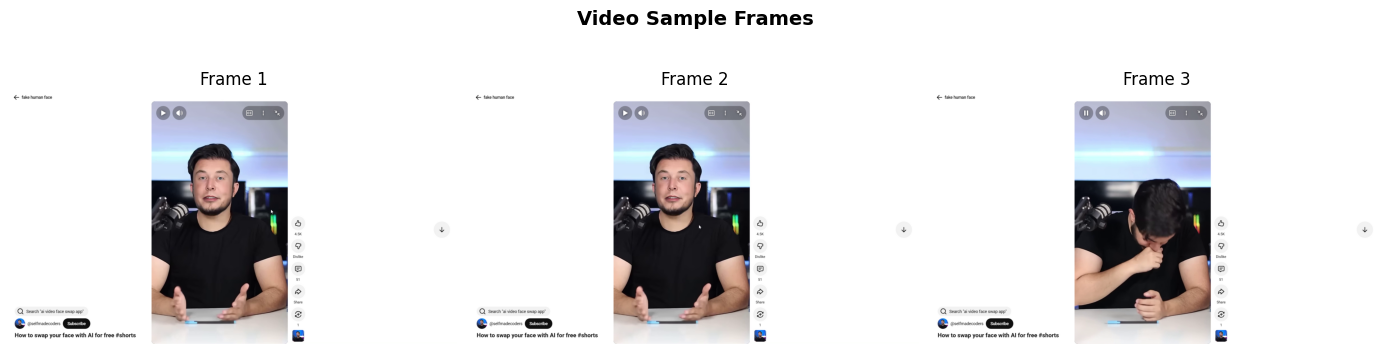


  FINAL VERDICT : 🟢 REAL
  Fake conf     : 0.5%
  Real conf     : 99.5%
  Modalities    : video
  Individual scores:
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 0.5%


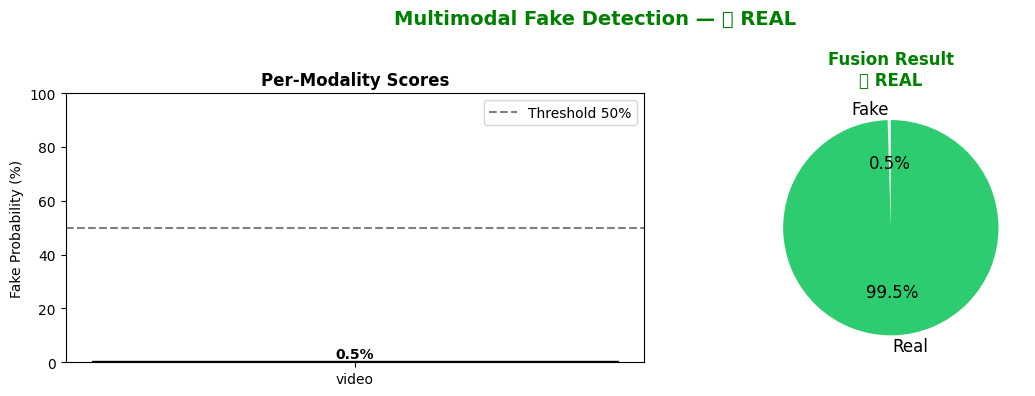

In [ ]:
from google.colab import files

print("📂 Upload any file — image, video, or text file")
print("   Or skip and type text directly below")
print("=" * 50)

uploaded = files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {fname}")

    # Auto detect and run
    if fname.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        print("🖼️  Detected: IMAGE")
        detect(image_path=fname)

    elif fname.lower().endswith(('.mp4','.avi','.mov','.mkv')):
        print("🎬 Detected: VIDEO")
        detect(video_path=fname)

else:
    # No file — test with text
    print("No file uploaded — running text test...")
    detect(text="Shocking: Scientists prove 5G towers control human minds!")

🧪 TEST 4 — Text + Video Combined

🎥 Upload a video to combine with text...


Saving WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4 to WhatsApp Video 2026-06-27 at 3.47.21 PM (2).mp4
Running multimodal fusion (text + video)...
   📝 Text  score : 100.0% fake
   🎬 Video score : 79.2% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 91.1%
  Real conf   : 8.9%
  Modalities  : text, video
------------------------------------------------------------
  Individual scores:
  📝 text  : ████████████████████ 100.0%
  🎬 video : ███████████████░░░░░ 79.2%


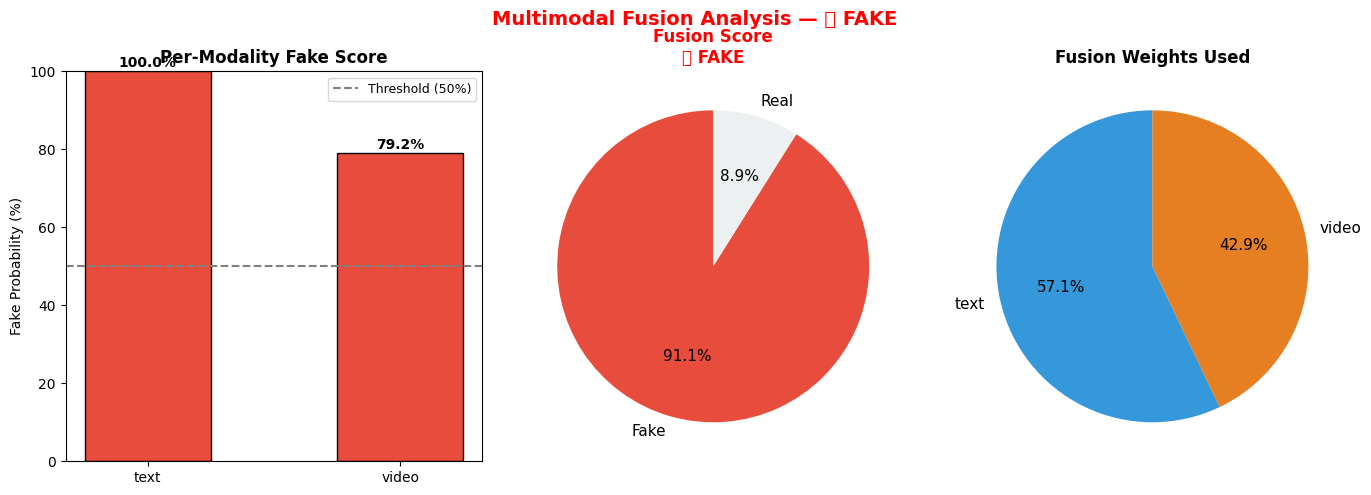


💡 Note how fusion combines both scores:
   Text alone would give: 100.0% fake
   Video alone would give: 79.17% fake
   Combined fusion score: 91.1% fake


In [ ]:
print("🧪 TEST 4 — Text + Video Combined\n")
print("🎥 Upload a video to combine with text...")

uploaded = files.upload()

if uploaded:
    video_path = list(uploaded.keys())[0]

    # Test with FAKE text + video
    fake_text = """
    Viral Image of Lord Hanuman Bowing Before Lord Rama Sparks Debate Online
    """

    print("Running multimodal fusion (text + video)...")
    result = multimodal_fusion(
        text=fake_text,
        video_path=video_path
    )

    display_fusion_result(result)

    print(f"\n💡 Note how fusion combines both scores:")
    print(f"   Text alone would give: "
          f"{result['individual_scores'].get('text', 'N/A')}% fake")
    print(f"   Video alone would give: "
          f"{result['individual_scores'].get('video', 'N/A')}% fake")
    print(f"   Combined fusion score: "
          f"{result['confidence_fake']:.1f}% fake")

🧪 TEST 5 — Image + Video Combined

📂 Upload an image...


Saving WhatsApp Image 2026-05-29 at 12.42.53 PM.jpeg to WhatsApp Image 2026-05-29 at 12.42.53 PM.jpeg

🎥 Upload a video...


Saving WhatsApp Video 2026-05-29 at 12.42.33 PM.mp4 to WhatsApp Video 2026-05-29 at 12.42.33 PM (1).mp4
Running multimodal fusion (image + video)...
   🖼️  Image score : 0.0% fake
   🎬 Video score : 0.0% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🟢 REAL
  Fake conf   : 0.0%
  Real conf   : 100.0%
  Modalities  : image, video
------------------------------------------------------------
  Individual scores:
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.0%
  🎬 video : ░░░░░░░░░░░░░░░░░░░░ 0.0%


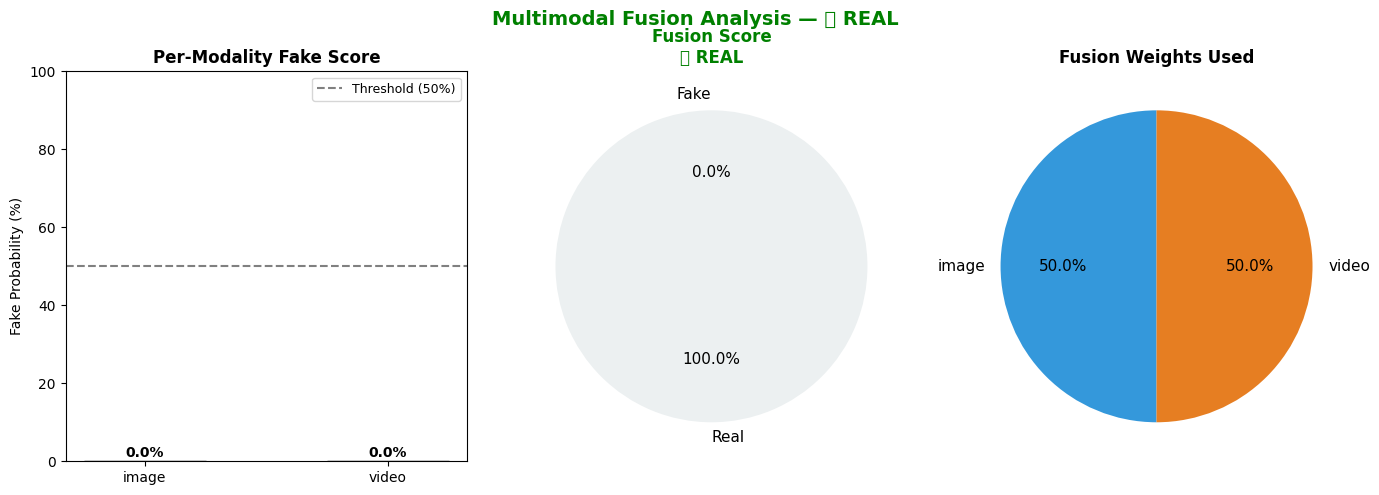


💡 Note how fusion combines both scores:
   Image alone would give: 0.0% fake
   Video alone would give: 0.0% fake
   Combined fusion score: 0.0% fake


In [ ]:
print("🧪 TEST 5 — Image + Video Combined\n")

print("📂 Upload an image...")
uploaded_image = files.upload()

if uploaded_image:
    image_path = list(uploaded_image.keys())[0]

    print("\n🎥 Upload a video...")
    uploaded_video = files.upload()

    if uploaded_video:
        video_path = list(uploaded_video.keys())[0]

        print("Running multimodal fusion (image + video)...")

        result = multimodal_fusion(
            image_path=image_path,
            video_path=video_path
        )

        display_fusion_result(result)

        print(f"\n💡 Note how fusion combines both scores:")
        print(f"   Image alone would give: "
              f"{result['individual_scores'].get('image', 'N/A')}% fake")
        print(f"   Video alone would give: "
              f"{result['individual_scores'].get('video', 'N/A')}% fake")
        print(f"   Combined fusion score: "
              f"{result['confidence_fake']:.1f}% fake")

TEST 1 — Text Only Prediction

Running text prediction...
   📝 Text  score : 100.0% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 100.0%
  Real conf   : 0.0%
  Modalities  : text
------------------------------------------------------------
  Individual scores:
  📝 text  : ████████████████████ 100.0%


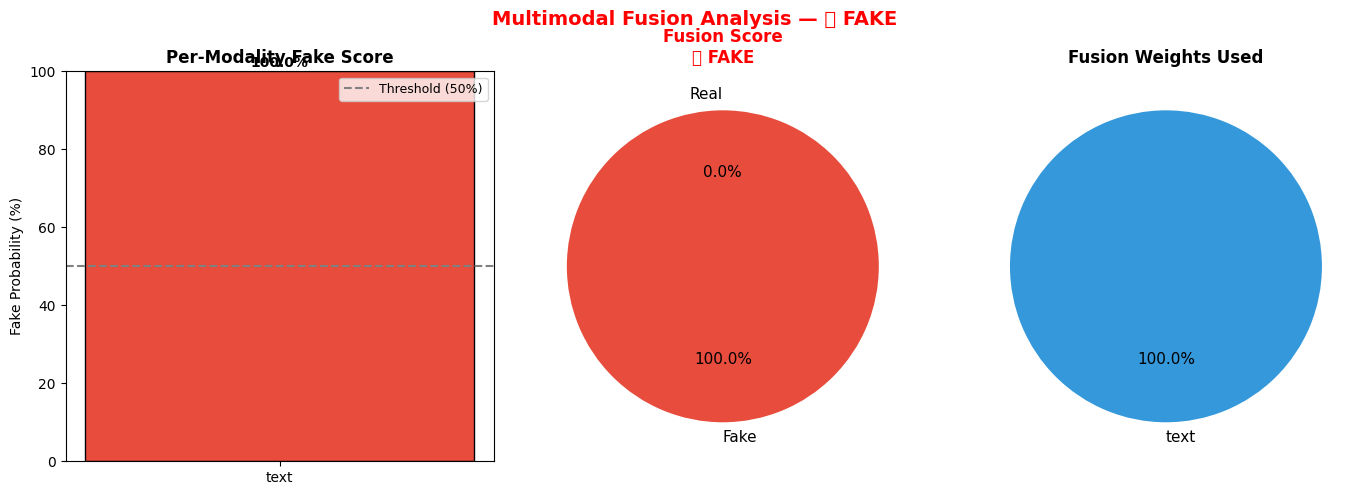


Text Fake Score : 100.0%
Final Fake Confidence : 100.0%


In [ ]:
print("TEST 1 — Text Only Prediction\n")

fake_text = """
Breaking News: Viral video shows two children riding a motorcycle without an adult driver, leaving people shocked across social media.
"""

print("Running text prediction...")

result = multimodal_fusion(text=fake_text)

display_fusion_result(result)

print(f"\nText Fake Score : {result['individual_scores'].get('text', 'N/A')}%")
print(f"Final Fake Confidence : {result['confidence_fake']:.1f}%")

TEST 2 — Image Only Prediction

Upload an image...


Saving ai image.jpg to ai image.jpg
Running image prediction...
   🖼️  Image score : 70.6% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 70.6%
  Real conf   : 29.4%
  Modalities  : image
------------------------------------------------------------
  Individual scores:
  🖼️ image : ██████████████░░░░░░ 70.6%


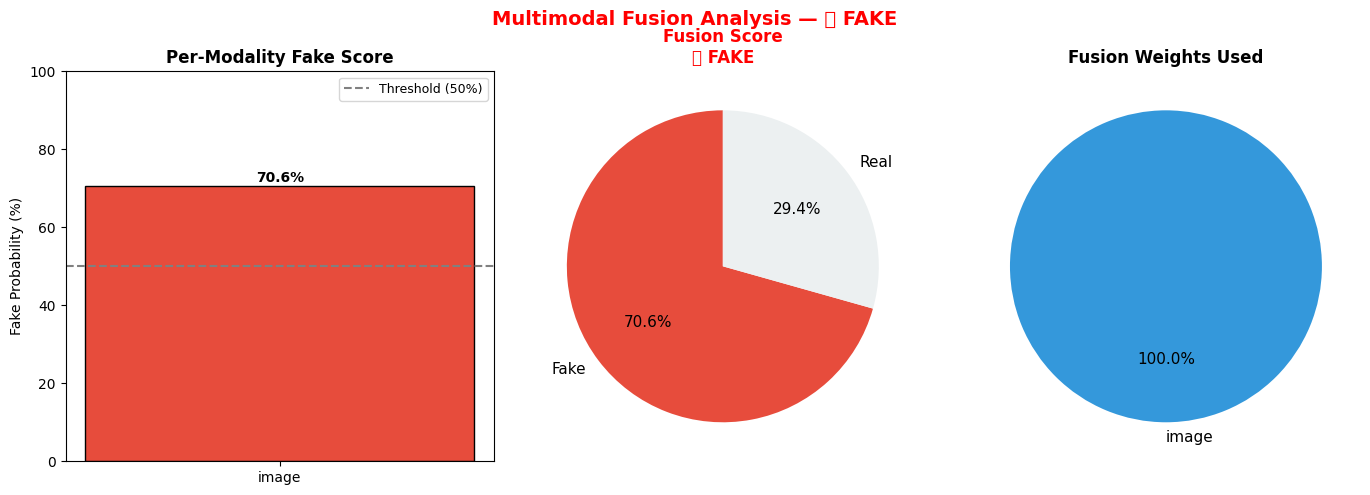


Image Fake Score : 70.63%
Final Fake Confidence : 70.6%


In [ ]:
print("TEST 2 — Image Only Prediction\n")

print("Upload an image...")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    print("Running image prediction...")

    result = multimodal_fusion(image_path=image_path)

    display_fusion_result(result)

    print(f"\nImage Fake Score : {result['individual_scores'].get('image', 'N/A')}%")
    print(f"Final Fake Confidence : {result['confidence_fake']:.1f}%")

TEST 3 — Video Only Prediction

Upload a video...


Saving WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4 to WhatsApp Video 2026-06-27 at 3.47.21 PM (3).mp4
Running video prediction...
   🎬 Video score : 79.2% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 79.2%
  Real conf   : 20.8%
  Modalities  : video
------------------------------------------------------------
  Individual scores:
  🎬 video : ███████████████░░░░░ 79.2%


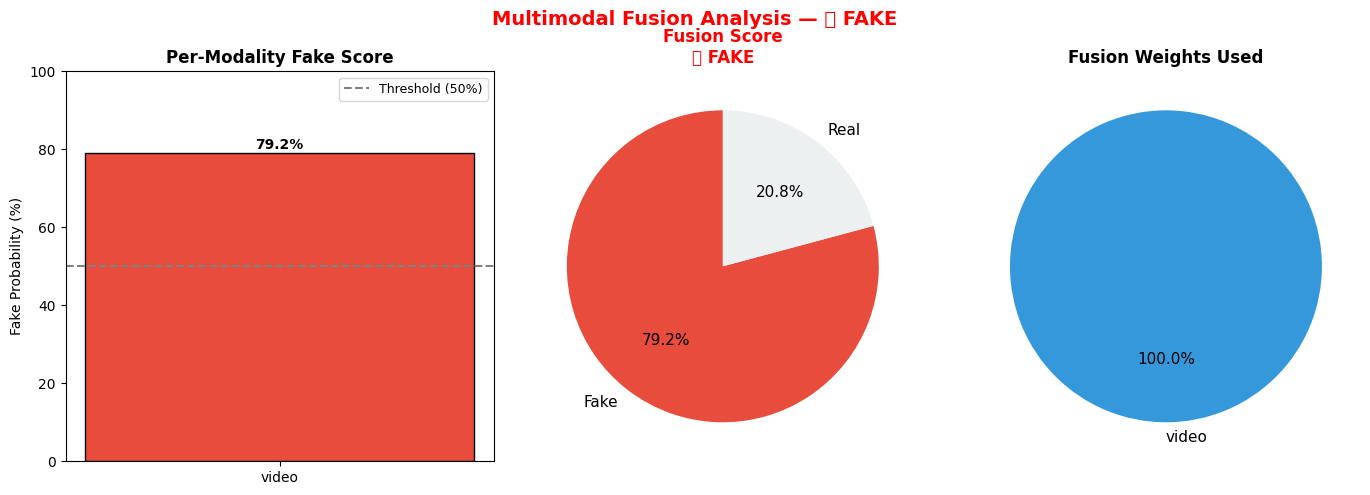


Video Fake Score : 79.17%
Final Fake Confidence : 79.2%


In [ ]:
print("TEST 3 — Video Only Prediction\n")

print("Upload a video...")
uploaded = files.upload()

if uploaded:
    video_path = list(uploaded.keys())[0]

    print("Running video prediction...")

    result = multimodal_fusion(video_path=video_path)

    display_fusion_result(result)

    print(f"\nVideo Fake Score : {result['individual_scores'].get('video', 'N/A')}%")
    print(f"Final Fake Confidence : {result['confidence_fake']:.1f}%")

TEST 4 — Text + Image Prediction

Upload an image...


Saving Screenshot 2026-07-07 183827.png to Screenshot 2026-07-07 183827.png
Running multimodal fusion...
   📝 Text  score : 100.0% fake
   🖼️  Image score : 0.7% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🔴 FAKE
  Fake conf   : 57.4%
  Real conf   : 42.6%
  Modalities  : text, image
------------------------------------------------------------
  Individual scores:
  📝 text  : ████████████████████ 100.0%
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.7%


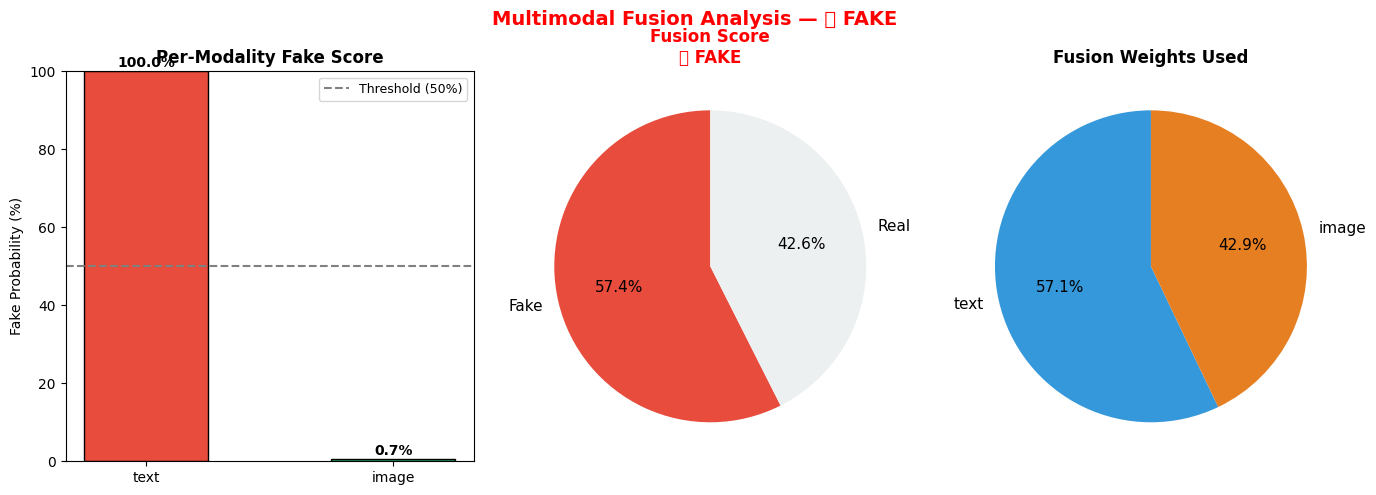


Text Score : 100.0%
Image Score : 0.7%
Final Fusion Score : 57.4%


In [ ]:
print("TEST 4 — Text + Image Prediction\n")

print("Upload an image...")
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    fake_text = """
    Breaking News: Viral video shows two children riding a motorcycle without an adult driver, leaving people shocked across social media.
    """

    print("Running multimodal fusion...")

    result = multimodal_fusion(
        text=fake_text,
        image_path=image_path
    )

    display_fusion_result(result)

    print(f"\nText Score : {result['individual_scores'].get('text', 'N/A')}%")
    print(f"Image Score : {result['individual_scores'].get('image', 'N/A')}%")
    print(f"Final Fusion Score : {result['confidence_fake']:.1f}%")

TEST 6 — Image + Video Prediction

Upload an image...


Saving WhatsApp Image 2026-07-07 at 6.41.28 PM.jpeg to WhatsApp Image 2026-07-07 at 6.41.28 PM.jpeg
Upload a video...


Saving WhatsApp Video 2026-07-07 at 6.41.28 PM.mp4 to WhatsApp Video 2026-07-07 at 6.41.28 PM.mp4
Running multimodal fusion...
   🖼️  Image score : 0.0% fake
   🎬 Video score : 7.8% fake

  🔍 MULTIMODAL FUSION RESULT
  Verdict     : 🟢 REAL
  Fake conf   : 3.9%
  Real conf   : 96.1%
  Modalities  : image, video
------------------------------------------------------------
  Individual scores:
  🖼️ image : ░░░░░░░░░░░░░░░░░░░░ 0.0%
  🎬 video : █░░░░░░░░░░░░░░░░░░░ 7.8%


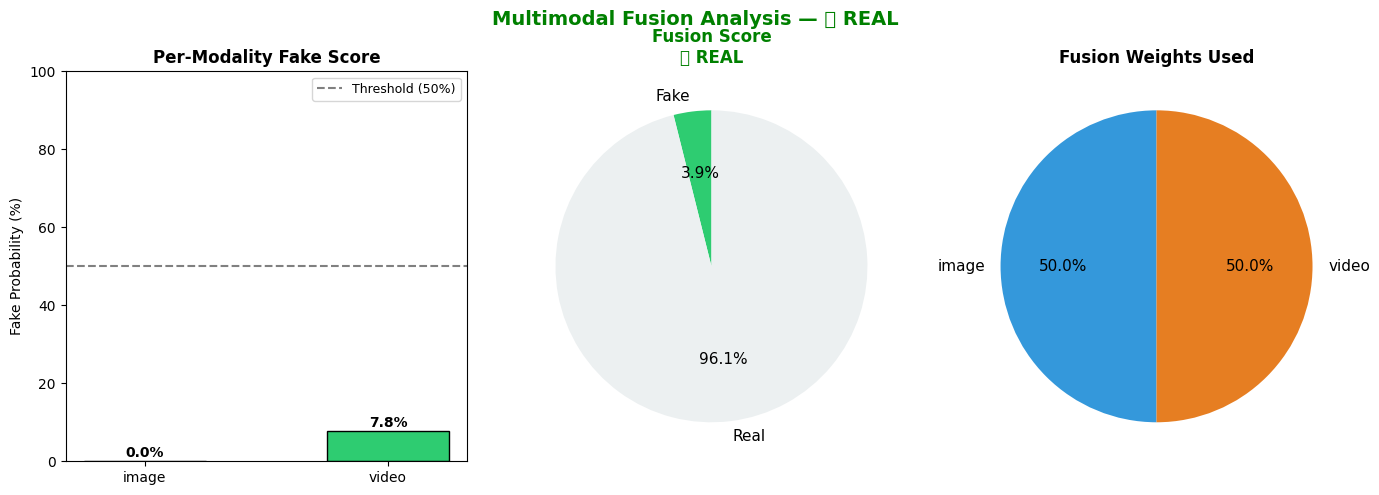


Image Score : 0.0%
Video Score : 7.81%
Final Fusion Score : 3.9%


In [ ]:
print("TEST 6 — Image + Video Prediction\n")

print("Upload an image...")
uploaded_image = files.upload()

if uploaded_image:
    image_path = list(uploaded_image.keys())[0]

    print("Upload a video...")
    uploaded_video = files.upload()

    if uploaded_video:
        video_path = list(uploaded_video.keys())[0]

        print("Running multimodal fusion...")

        result = multimodal_fusion(
            image_path=image_path,
            video_path=video_path
        )

        display_fusion_result(result)

        print(f"\nImage Score : {result['individual_scores'].get('image', 'N/A')}%")
        print(f"Video Score : {result['individual_scores'].get('video', 'N/A')}%")
        print(f"Final Fusion Score : {result['confidence_fake']:.1f}%")

In [ ]:
# ── Imports ──────────────────────────────────────────────────
import os, cv2, torch, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn as nn
from torchvision import transforms, models
from transformers import BertTokenizer, BertForSequenceClassification
from PIL import Image
from google.colab import drive, files
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BASE_PATH  = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
BERT_PATH  = os.path.join(BASE_PATH, "models/bert_model")
CNN_PATH   = os.path.join(BASE_PATH, "models/cnn_model/efficientnet_v3_best.pth")

Mounted at /content/drive
Device: cuda


In [ ]:
# ── Load Models ───────────────────────────────────────────────
print("Loading models...")

# BERT
tokenizer  = BertTokenizer.from_pretrained(BERT_PATH)
bert_model = BertForSequenceClassification.from_pretrained(BERT_PATH)
bert_model = bert_model.to(device)
bert_model.eval()
print("✅ BERT loaded!")

# EfficientNetB0 V3
def build_efficientnet():
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for p in m.parameters(): p.requires_grad = False
    for p in m.features[5:].parameters(): p.requires_grad = True
    inf = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(inf,512),
        nn.ReLU(), nn.Dropout(0.15), nn.Linear(512,2))
    return m

cnn_model = build_efficientnet()
w = torch.load(CNN_PATH, map_location=device)
if any(k.startswith('module.') for k in w.keys()):
    w = {k.replace('module.',''):v for k,v in w.items()}
cnn_model.load_state_dict(w)
cnn_model = cnn_model.to(device)
cnn_model.eval()
print("✅ CNN V3 loaded!")

Loading models...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BERT loaded!
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 68.3MB/s]


✅ CNN V3 loaded!


In [ ]:
# ── Transforms + Prediction Functions ─────────────────────────
base_tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
flip_tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
crop_tfm = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def predict_text(text):
    e = tokenizer(text.lower().strip(), max_length=128,
                  truncation=True, padding='max_length',
                  return_tensors='pt')
    with torch.no_grad():
        p = torch.softmax(bert_model(
            input_ids=e['input_ids'].to(device),
            attention_mask=e['attention_mask'].to(device)
        ).logits, dim=1)
    return float(p[0][1])   # fake probability

def predict_image(pil_img):
    probs = []
    for tfm in [base_tfm, flip_tfm, crop_tfm]:
        t = tfm(pil_img.convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            p = torch.softmax(cnn_model(t), dim=1)
        probs.append(p[0].cpu().numpy())
    avg = np.mean(probs, axis=0)
    return float(avg[0])   # fake probability

def predict_video(path, n=20):
    cap   = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    dur   = total/fps if fps > 0 else 0
    if total == 0:
        cap.release(); return None, 0
    fake_probs = []
    for idx in np.linspace(0, total-1, min(n,total), dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            fake_probs.append(predict_image(img))
    cap.release()
    return (float(np.mean(fake_probs)) if fake_probs else None), dur

print("✅ All prediction functions ready!")

✅ All prediction functions ready!


In [ ]:
# ── Fusion Visualisation Function ─────────────────────────────
def run_fusion(scores_dict, weights_dict,
               title_suffix="", show_image=None, save_path=None):
    """
    scores_dict  : {'text': 0.93, 'image': 0.02, 'video': 0.45}
    weights_dict : {'text': 0.4,  'image': 0.3,  'video': 0.3 }
    """
    # Auto-normalise weights
    active_keys = list(scores_dict.keys())
    total_w     = sum(weights_dict[k] for k in active_keys)
    norm_weights = {k: weights_dict[k]/total_w for k in active_keys}

    # Weighted fusion score
    fusion_score = sum(scores_dict[k]*norm_weights[k] for k in active_keys)
    fake_pct     = fusion_score * 100
    real_pct     = (1 - fusion_score) * 100
    verdict      = "REAL" if fusion_score < 0.5 else "FAKE"
    verdict_icon = "✅" if verdict=="REAL" else "⚠️"
    v_color      = "green" if verdict=="REAL" else "red"

    # ── Figure layout ─────────────────────────────────────────
    n_cols = 4 if show_image else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    fig.suptitle(
        f"Multimodal Fusion Analysis — {verdict_icon} {verdict}\n"
        f"Fusion Score\n{verdict_icon} {verdict}",
        fontsize=13, fontweight='bold', color=v_color, y=1.02)

    # ── Plot 1: Bar chart per modality ─────────────────────────
    ax1 = axes[0]
    modalities  = active_keys
    fake_scores = [scores_dict[k]*100 for k in modalities]
    bar_colors  = ['red' if s >= 50 else '#2196F3' for s in fake_scores]
    bars = ax1.bar(modalities, fake_scores, color=bar_colors,
                   edgecolor='black', linewidth=0.7, width=0.5)
    for bar, s in zip(bars, fake_scores):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f'{s:.1f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.axhline(y=50, color='gray', linestyle='--',
                linewidth=1.2, label='Threshold (50%)')
    ax1.set_ylim([0, 110])
    ax1.set_ylabel('Fake Probability (%)', fontsize=10)
    ax1.set_title('Per-Modality Fake Score', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ── Plot 2: Fusion pie chart ───────────────────────────────
    ax2 = axes[1]
    pie_colors = ['#4CAF50', '#F44336'] if verdict=="REAL" else ['#F44336','#4CAF50']
    wedges, texts, autotexts = ax2.pie(
        [real_pct, fake_pct] if verdict=="REAL" else [fake_pct, real_pct],
        labels=['Real','Fake'] if verdict=="REAL" else ['Fake','Real'],
        autopct='%1.1f%%', colors=pie_colors,
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(linewidth=1.2, edgecolor='white'))
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
    ax2.set_title('Fusion Score', fontsize=11, fontweight='bold')
    # Centre verdict text
    ax2.text(0, 0, f'{verdict_icon}\n{verdict}',
             ha='center', va='center',
             fontsize=12, fontweight='bold', color=v_color)

    # ── Plot 3: Fusion weights pie ─────────────────────────────
    ax3 = axes[2]
    w_labels  = [f"{k}\n({norm_weights[k]*100:.1f}%)" for k in active_keys]
    w_sizes   = [norm_weights[k]*100 for k in active_keys]
    w_colors  = ['#2196F3','#FF9800','#9C27B0','#4CAF50'][:len(active_keys)]
    ax3.pie(w_sizes, labels=[k for k in active_keys],
            autopct='%1.1f%%', colors=w_colors,
            startangle=90, pctdistance=0.7,
            wedgeprops=dict(linewidth=1.2, edgecolor='white'))
    ax3.set_title('Fusion Weights Used', fontsize=11, fontweight='bold')

    # ── Plot 4: Uploaded image (optional) ─────────────────────
    if show_image is not None and n_cols == 4:
        ax4 = axes[3]
        ax4.imshow(show_image)
        ax4.axis('off')
        result_label = f"{verdict_icon} {verdict}\nFake: {fake_pct:.1f}%"
        ax4.set_title(result_label, fontsize=11,
                      fontweight='bold', color=v_color)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    plt.show()
    plt.close()

    # ── Summary printout ──────────────────────────────────────
    print("="*55)
    print(f"  FUSION RESULT : {verdict_icon} {verdict}")
    print(f"  Fusion score  : {fusion_score*100:.1f}%")
    print(f"  Fake conf     : {fake_pct:.1f}%")
    print(f"  Real conf     : {real_pct:.1f}%")
    print("-"*55)
    for k in active_keys:
        print(f"  {k:<8}: {scores_dict[k]*100:.1f}% fake "
              f"(weight {norm_weights[k]*100:.0f}%)")
    print("="*55)
    return fusion_score

print("✅ Fusion visualisation function ready!")

✅ Fusion visualisation function ready!



Upload ONE image for Text + Image fusion test...


Saving 0019.jpg to 0019 (1).jpg

Running Text + Image Fusion...
  Text  fake score : 100.0%
  Image fake score : 99.8%
✅ Saved: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs/fusion_text_image.png


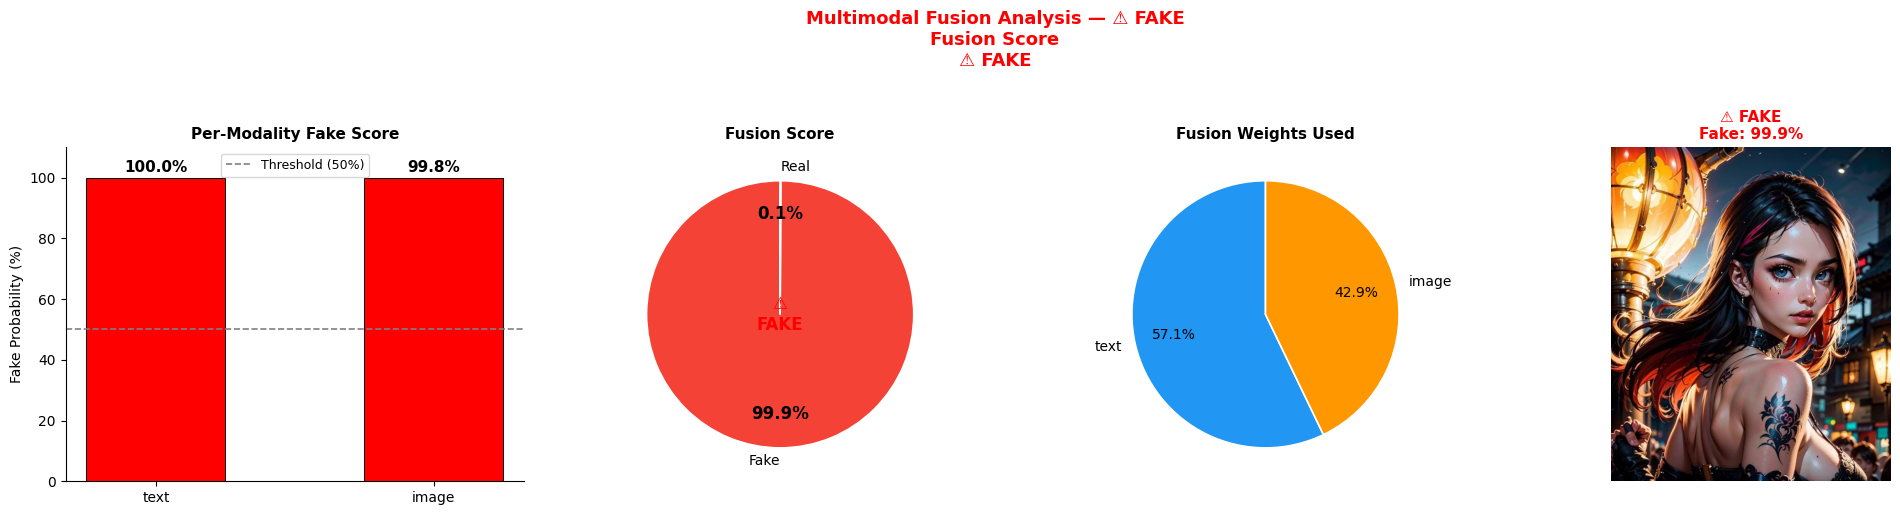

  FUSION RESULT : ⚠️ FAKE
  Fusion score  : 99.9%
  Fake conf     : 99.9%
  Real conf     : 0.1%
-------------------------------------------------------
  text    : 100.0% fake (weight 57%)
  image   : 99.8% fake (weight 43%)


0.9992480703762601

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.5.2  Text + Image Prediction
# ══════════════════════════════════════════════════════════════
print("\nUpload ONE image for Text + Image fusion test...")
uploaded = files.upload()
img_fname = list(uploaded.keys())[0]
pil_img   = Image.open(img_fname).convert('RGB')

# ── Provide your text here ────────────────────────────────────
text_input = "Scientists Reveal the World's First AI-Engineered Human Living Among Us"

print("\nRunning Text + Image Fusion...")
text_score  = predict_text(text_input)
image_score = predict_image(pil_img)

print(f"  Text  fake score : {text_score*100:.1f}%")
print(f"  Image fake score : {image_score*100:.1f}%")

GRAPHS = os.path.join(BASE_PATH, "outputs/graphs")
os.makedirs(GRAPHS, exist_ok=True)

run_fusion(
    scores_dict  = {'text': text_score, 'image': image_score},
    weights_dict = {'text': 0.4, 'image': 0.3, 'video': 0.3},
    title_suffix = "Text + Image",
    show_image   = pil_img,
    save_path    = f"{GRAPHS}/fusion_text_image.png"
)


📂 Upload ONE video for Text + Video fusion test...


Saving WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4 to WhatsApp Video 2026-06-27 at 3.47.21 PM.mp4

🔍 Running Text + Video Fusion...
  Text  fake score : 100.0%
  Video fake score : 97.1% (13.6s)
✅ Saved: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs/fusion_text_video.png


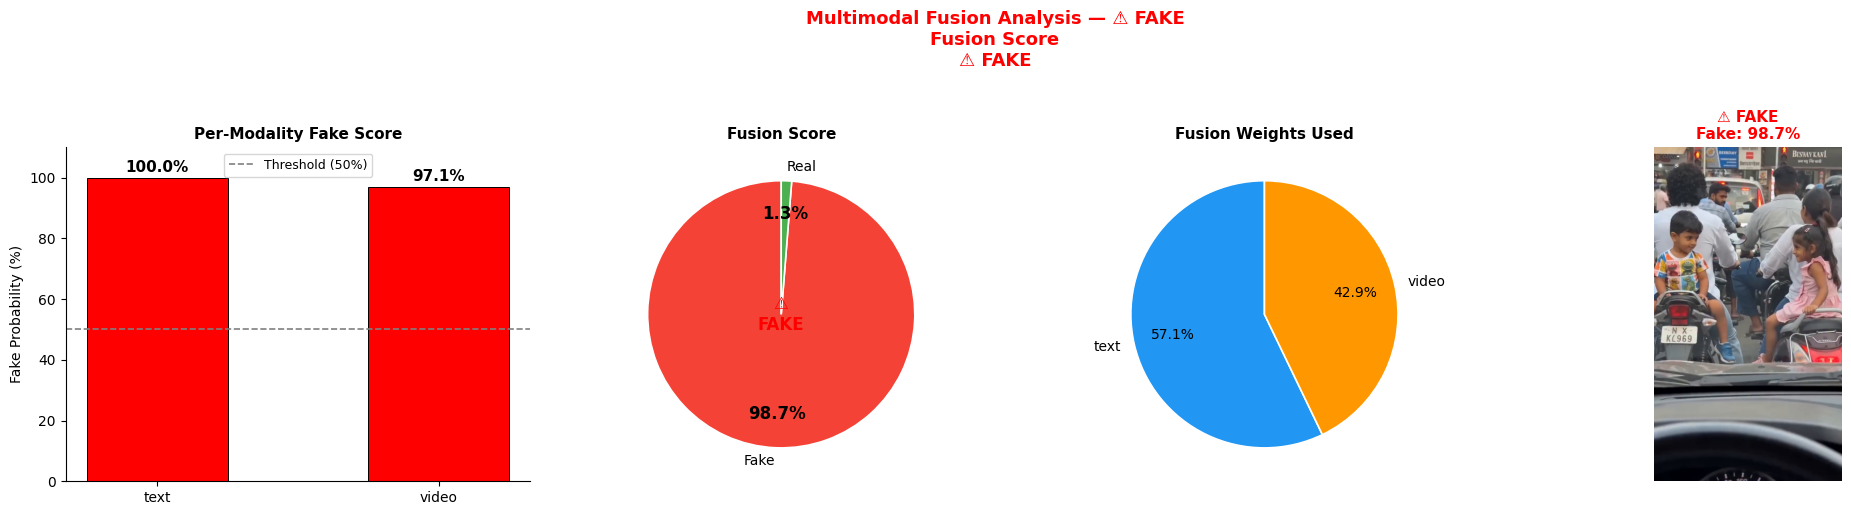

  FUSION RESULT : ⚠️ FAKE
  Fusion score  : 98.7%
  Fake conf     : 98.7%
  Real conf     : 1.3%
-------------------------------------------------------
  text    : 100.0% fake (weight 57%)
  video   : 97.1% fake (weight 43%)


0.9874765408890589

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.5.3  Text + Video Prediction
# ══════════════════════════════════════════════════════════════
import tempfile

print("\n📂 Upload ONE video for Text + Video fusion test...")
uploaded   = files.upload()
vid_fname  = list(uploaded.keys())[0]
with tempfile.NamedTemporaryFile(delete=False, suffix='.mp4') as tmp:
    tmp.write(open(vid_fname,'rb').read())
    tmp_path = tmp.name

text_input2 = "Shocking Video Captures Children Floating in the Air During Traffic Jam"

print("\n🔍 Running Text + Video Fusion...")
text_score2  = predict_text(text_input2)
video_score, dur = predict_video(tmp_path)
os.unlink(tmp_path)

print(f"  Text  fake score : {text_score2*100:.1f}%")
print(f"  Video fake score : {video_score*100:.1f}% ({dur:.1f}s)")

# Extract first frame to show
cap = cv2.VideoCapture(vid_fname)
ret, frame = cap.read()
cap.release()
frame_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) if ret else None

run_fusion(
    scores_dict  = {'text': text_score2, 'video': video_score},
    weights_dict = {'text': 0.4, 'image': 0.3, 'video': 0.3},
    title_suffix = "Text + Video",
    show_image   = frame_img,
    save_path    = f"{GRAPHS}/fusion_text_video.png"
)


📂 Upload ONE image...


Saving WhatsApp Image 2026-07-07 at 6.41.28 PM.jpeg to WhatsApp Image 2026-07-07 at 6.41.28 PM.jpeg
📂 Upload ONE video...


Saving WhatsApp Video 2026-07-07 at 6.41.28 PM.mp4 to WhatsApp Video 2026-07-07 at 6.41.28 PM (1).mp4

🔍 Running Image + Video Fusion...
  Image fake score : 99.3%
  Video fake score : 95.8%
✅ Saved: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs/fusion_image_video.png


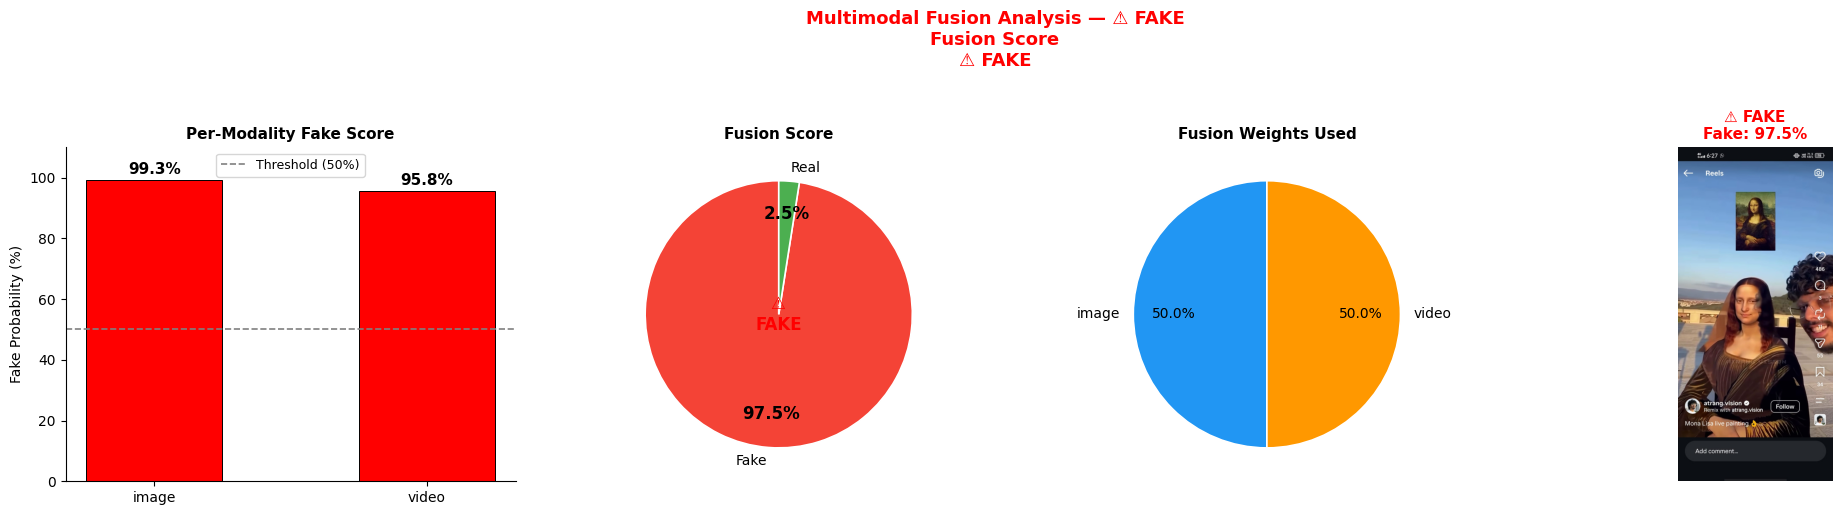

  FUSION RESULT : ⚠️ FAKE
  Fusion score  : 97.5%
  Fake conf     : 97.5%
  Real conf     : 2.5%
-------------------------------------------------------
  image   : 99.3% fake (weight 50%)
  video   : 95.8% fake (weight 50%)


0.9753082096576691

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.5.6  Image + Video Prediction
# ══════════════════════════════════════════════════════════════
print("\n📂 Upload ONE image...")
up1 = files.upload()
img2 = Image.open(list(up1.keys())[0]).convert('RGB')

print("📂 Upload ONE video...")
up2 = files.upload()
vid2 = list(up2.keys())[0]
with tempfile.NamedTemporaryFile(delete=False, suffix='.mp4') as tmp:
    tmp.write(open(vid2,'rb').read()); tp2 = tmp.name

print("\n🔍 Running Image + Video Fusion...")
image_score2 = predict_image(img2)
video_score2, dur2 = predict_video(tp2)
os.unlink(tp2)

print(f"  Image fake score : {image_score2*100:.1f}%")
print(f"  Video fake score : {video_score2*100:.1f}%")

run_fusion(
    scores_dict  = {'image': image_score2, 'video': video_score2},
    weights_dict = {'text': 0.4, 'image': 0.3, 'video': 0.3},
    title_suffix = "Image + Video",
    show_image   = img2,
    save_path    = f"{GRAPHS}/fusion_image_video.png"
)


📂 Upload ONE image for full fusion test...


Saving WhatsApp Image 2026-07-11 at 4.19.47 PM.jpeg to WhatsApp Image 2026-07-11 at 4.19.47 PM.jpeg
📂 Upload ONE video...


Saving WhatsApp Video 2026-07-11 at 4.15.51 PM.mp4 to WhatsApp Video 2026-07-11 at 4.15.51 PM (1).mp4

🔍 Running Full Multimodal Fusion (Text + Image + Video)...
  Text  fake score : 99.6%
  Image fake score : 78.6%
  Video fake score : 89.8%
✅ Saved: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs/fusion_text_image_video.png


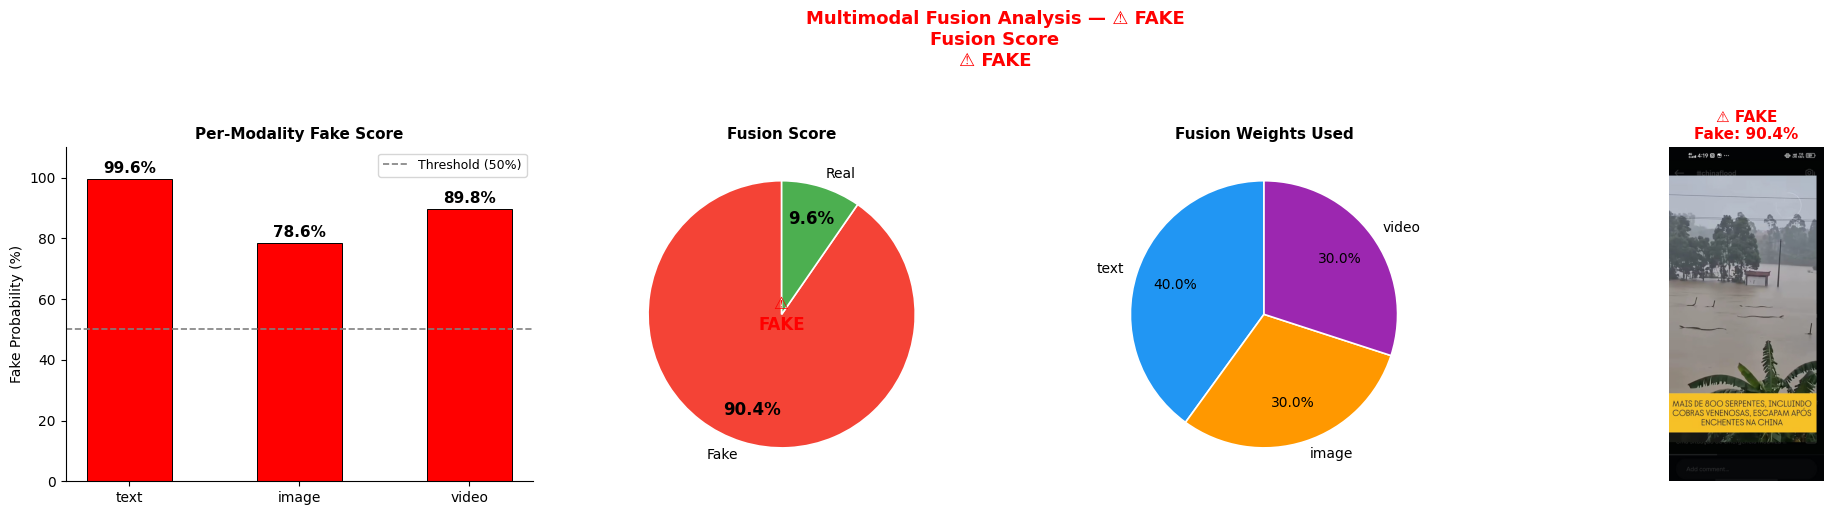

  FUSION RESULT : ⚠️ FAKE
  Fusion score  : 90.4%
  Fake conf     : 90.4%
  Real conf     : 9.6%
-------------------------------------------------------
  text    : 99.6% fake (weight 40%)
  image   : 78.6% fake (weight 30%)
  video   : 89.8% fake (weight 30%)

✅ All fusion snapshots saved to Drive!
   Location: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs
   Files:
   ✅ fusion_text_image.png
   ✅ fusion_text_video.png
   ✅ fusion_image_video.png
   ✅ fusion_text_image_video.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.5.7  Text + Image + Video Prediction (Full Fusion)
# ══════════════════════════════════════════════════════════════
print("\n📂 Upload ONE image for full fusion test...")
up3 = files.upload()
img3 = Image.open(list(up3.keys())[0]).convert('RGB')

print("📂 Upload ONE video...")
up4 = files.upload()
vid4 = list(up4.keys())[0]
with tempfile.NamedTemporaryFile(delete=False, suffix='.mp4') as tmp:
    tmp.write(open(vid4,'rb').read()); tp4 = tmp.name

text_input3 = "Breaking: Over 900 Snakes, With Venomous cobras, Escape Into Floodwaters After Dam Breach Hits Farm. China's Flood Crisis Turns Deadlier."

print("\n🔍 Running Full Multimodal Fusion (Text + Image + Video)...")
text_score3  = predict_text(text_input3)
image_score3 = predict_image(img3)
video_score3, dur3 = predict_video(tp4)
os.unlink(tp4)

print(f"  Text  fake score : {text_score3*100:.1f}%")
print(f"  Image fake score : {image_score3*100:.1f}%")
print(f"  Video fake score : {video_score3*100:.1f}%")

run_fusion(
    scores_dict  = {
        'text' : text_score3,
        'image': image_score3,
        'video': video_score3
    },
    weights_dict = {'text': 0.4, 'image': 0.3, 'video': 0.3},
    title_suffix = "Text + Image + Video",
    show_image   = img3,
    save_path    = f"{GRAPHS}/fusion_text_image_video.png"
)

print("\n✅ All fusion snapshots saved to Drive!")
print(f"   Location: {GRAPHS}")
print("   Files:")
for f in ['fusion_text_image.png','fusion_text_video.png',
          'fusion_image_video.png','fusion_text_image_video.png']:
    p = os.path.join(GRAPHS, f)
    if os.path.exists(p):
        print(f"   ✅ {f}")


  8.5.2  TEXT-ONLY PREDICTION


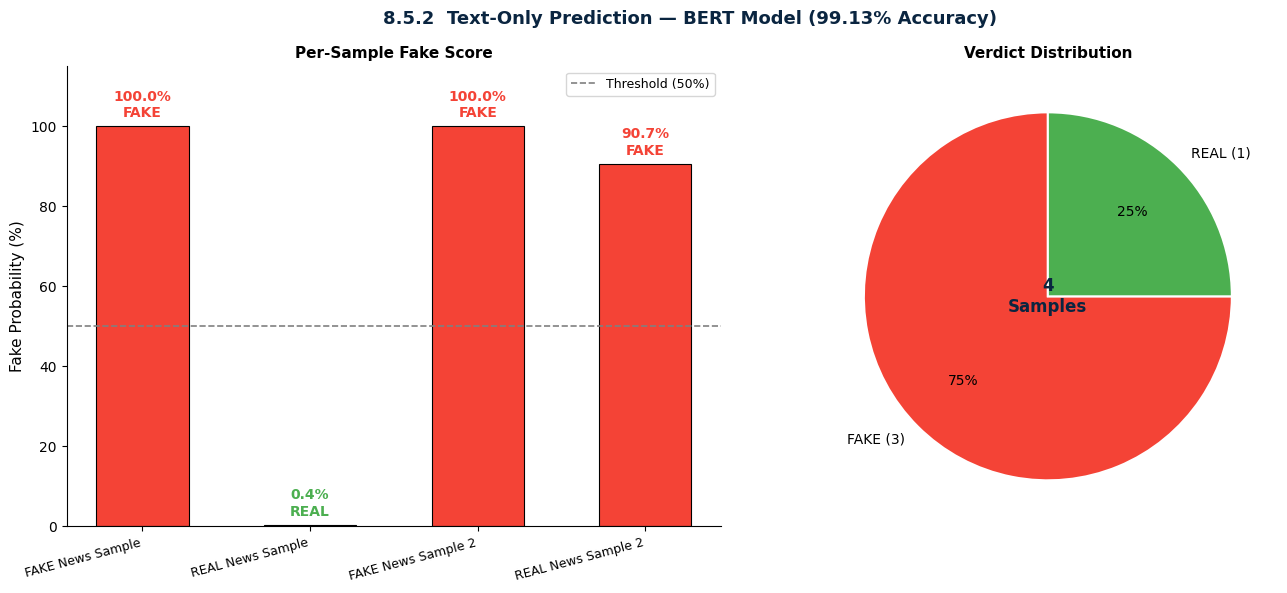

✅ Saved: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs/text_only_prediction.png

  Sample                   Fake Score    Verdict
------------------------------------------------------------
  FAKE News Sample            100.0%       FAKE
  REAL News Sample              0.4%       REAL
  FAKE News Sample 2          100.0%       FAKE
  REAL News Sample 2           90.7%       FAKE

  BERT Model Accuracy : 99.13%
  Fusion weight used  : Text = 100% (single modality)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.5.2  TEXT-ONLY PREDICTION
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  8.5.2  TEXT-ONLY PREDICTION")
print("="*60)

test_texts = [
    {
        "label": "FAKE News Sample",
        "text": "SHOCKING: Scientists prove 5G towers control human minds. Secret WHO documents confirm COVID vaccines contain microchips activated by 5G signals. Share before deleted!"
    },
    {
        "label": "REAL News Sample",
        "text": "The Federal Reserve raised interest rates by 25 basis points on Wednesday as policymakers continued efforts to bring inflation back to the central bank's 2 percent target."
    },
    {
        "label": "FAKE News Sample 2",
        "text": "Government hiding alien contact — whistleblower shares exclusive evidence. World leaders met secretly last month to discuss extraterrestrial invasion plans."
    },
    {
        "label": "REAL News Sample 2",
        "text": "Scientists at NASA successfully launched the Artemis II mission carrying four astronauts on a lunar flyby, marking the first crewed Moon mission since Apollo 17 in 1972."
    }
]

# Run predictions
results = []
for item in test_texts:
    score = predict_text(item['text'])
    verdict = "FAKE" if score >= 0.5 else "REAL"
    results.append({
        'label'  : item['label'],
        'text'   : item['text'],
        'score'  : score,
        'verdict': verdict
    })

# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("8.5.2  Text-Only Prediction — BERT Model (99.13% Accuracy)",
             fontsize=13, fontweight='bold', color='#0A2540')

# Bar chart
labels      = [r['label'] for r in results]
fake_scores = [r['score']*100 for r in results]
bar_colors  = ['#F44336' if s>=50 else '#4CAF50' for s in fake_scores]

bars = axes[0].bar(range(len(results)), fake_scores,
                   color=bar_colors, edgecolor='black',
                   linewidth=0.8, width=0.55)
for i, (bar, s, r) in enumerate(zip(bars, fake_scores, results)):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1.5,
                 f"{s:.1f}%\n{r['verdict']}",
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold',
                 color='#F44336' if s>=50 else '#4CAF50')
axes[0].axhline(y=50, color='gray', linestyle='--',
                linewidth=1.2, label='Threshold (50%)')
axes[0].set_xticks(range(len(results)))
axes[0].set_xticklabels(labels, fontsize=9,
                         rotation=15, ha='right')
axes[0].set_ylim([0, 115])
axes[0].set_ylabel('Fake Probability (%)', fontsize=11)
axes[0].set_title('Per-Sample Fake Score', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie summary
fake_count = sum(1 for r in results if r['verdict']=='FAKE')
real_count = len(results) - fake_count
axes[1].pie(
    [fake_count, real_count],
    labels=[f'FAKE ({fake_count})', f'REAL ({real_count})'],
    autopct='%1.0f%%',
    colors=['#F44336','#4CAF50'],
    startangle=90, pctdistance=0.65,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'))
axes[1].set_title('Verdict Distribution', fontsize=11, fontweight='bold')
axes[1].text(0, 0, f'{len(results)}\nSamples', ha='center',
             va='center', fontsize=12, fontweight='bold', color='#0A2540')

plt.tight_layout()
save_path = os.path.join(GRAPHS, "text_only_prediction.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Saved: {save_path}")

# Summary table
print("\n" + "="*60)
print(f"  {'Sample':<22} {'Fake Score':>12} {'Verdict':>10}")
print("-"*60)
for r in results:
    print(f"  {r['label']:<22} {r['score']*100:>10.1f}% {r['verdict']:>10}")
print("="*60)
print(f"\n  BERT Model Accuracy : 99.13%")
print(f"  Fusion weight used  : Text = 100% (single modality)")


  8.5.2  IMAGE-ONLY PREDICTION
📂 Upload your test images (fake + real — upload multiple)...


Saving a949303df9fca80e03c0affe7bbad12a.jpg to a949303df9fca80e03c0affe7bbad12a.jpg
  a949303df9fca80e03c0affe7bbad12a.jpg: REAL (4.3% fake)


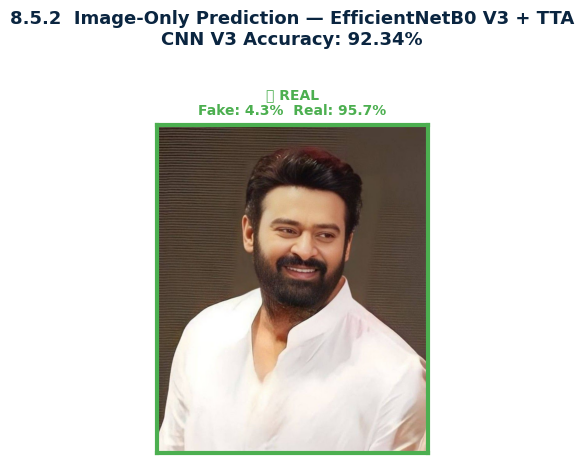


✅ Saved: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs/image_only_prediction.png

  Image                            Fake Score    Verdict
------------------------------------------------------------
  a949303df9fca80e03c0affe7bba          4.3%       REAL

  CNN V3 Accuracy     : 92.34%
  Method              : TTA 3-pass (base, flip, crop)
  Fusion weight used  : Image = 100% (single modality)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.5.2  IMAGE-ONLY PREDICTION
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  8.5.2  IMAGE-ONLY PREDICTION")
print("="*60)

print("📂 Upload your test images (fake + real — upload multiple)...")
uploaded = files.upload()

img_results = []
for fname in uploaded.keys():
    pil = Image.open(fname).convert('RGB')
    score = predict_image(pil)
    verdict = "FAKE" if score >= 0.5 else "REAL"
    img_results.append({
        'fname'  : fname,
        'pil'    : pil,
        'score'  : score,
        'verdict': verdict
    })
    print(f"  {fname}: {verdict} ({score*100:.1f}% fake)")

n = len(img_results)
cols = min(n, 4)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols,
                          figsize=(4.5*cols, 4.5*rows))
fig.suptitle("8.5.2  Image-Only Prediction — EfficientNetB0 V3 + TTA\n"
             "CNN V3 Accuracy: 92.34%",
             fontsize=13, fontweight='bold', color='#0A2540', y=1.02)

# Flatten axes
if n == 1:
    axes = [axes]
elif rows == 1:
    axes = list(axes)
else:
    axes = [ax for row in axes for ax in row]

for i, r in enumerate(img_results):
    v_color = '#F44336' if r['verdict']=='FAKE' else '#4CAF50'
    icon    = '⚠️' if r['verdict']=='FAKE' else '✅'
    axes[i].imshow(r['pil'])
    axes[i].set_title(
        f"{icon} {r['verdict']}\nFake: {r['score']*100:.1f}%  Real: {(1-r['score'])*100:.1f}%",
        fontsize=10, fontweight='bold', color=v_color, pad=8)
    # Coloured border
    for spine in axes[i].spines.values():
        spine.set_edgecolor(v_color)
        spine.set_linewidth(3)
    axes[i].set_xticks([]); axes[i].set_yticks([])

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = os.path.join(GRAPHS, "image_only_prediction.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"\n✅ Saved: {save_path}")

print("\n" + "="*60)
print(f"  {'Image':<30} {'Fake Score':>12} {'Verdict':>10}")
print("-"*60)
for r in img_results:
    print(f"  {r['fname'][:28]:<30} {r['score']*100:>10.1f}% {r['verdict']:>10}")
print("="*60)
print(f"\n  CNN V3 Accuracy     : 92.34%")
print(f"  Method              : TTA 3-pass (base, flip, crop)")
print(f"  Fusion weight used  : Image = 100% (single modality)")